In [1]:
# NOTE: This file is the source for three Jupyter notebook cells.
# Copy each section into its own cell.
# =============================================================================

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports · API path · Global parameters · Fixed refractive indices ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys
import os
import platform
import time
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import h5py

# ─────────────────────────────────────────────────────────────────────────────
# Lumerical installation paths
# ► Set LUMERICAL_VERSION to exactly match your installation folder name.
#   Check:  C:\Program Files\Lumerical\   and read the subfolder name.
# ─────────────────────────────────────────────────────────────────────────────
LUMERICAL_VERSION = "v202"          # ← confirmed from your traceback

if platform.system() == "Windows":
    LUMERICAL_ROOT = rf"C:\Program Files\Lumerical\{LUMERICAL_VERSION}"
    LUMERICAL_API  = rf"{LUMERICAL_ROOT}\api\python"
    LUMERICAL_BIN  = rf"{LUMERICAL_ROOT}\bin"
else:
    LUMERICAL_ROOT = f"/opt/lumerical/{LUMERICAL_VERSION}"
    LUMERICAL_API  = f"{LUMERICAL_ROOT}/api/python"
    LUMERICAL_BIN  = f"{LUMERICAL_ROOT}/bin"

# ── 1. Clear any previously cached failed import ─────────────────────────────
# If lumapi was imported and failed in this kernel session, Python stores the
# broken module in sys.modules and returns the same failure on every retry.
# Removing it forces a clean re-import.
if "lumapi" in sys.modules:
    del sys.modules["lumapi"]

# ── 2. Add the API folder to sys.path ────────────────────────────────────────
if LUMERICAL_API not in sys.path:
    sys.path.insert(0, LUMERICAL_API)

# ── 3. Register the bin directory as a DLL search path ───────────────────────
# REQUIRED on Python 3.8+ (you are on 3.11).
# os.environ["PATH"] manipulation does NOT work for CDLL() from Python 3.8
# onwards — Windows changed DLL resolution to ignore PATH by default.
# os.add_dll_directory() is the correct API.
if platform.system() == "Windows":
    if hasattr(os, "add_dll_directory"):          # Python 3.8+  ← your case
        os.add_dll_directory(str(LUMERICAL_BIN))
    else:                                          # Python < 3.8 fallback
        os.environ["PATH"] = (
            str(LUMERICAL_BIN) + ";" + os.environ.get("PATH", "")
        )

# ── 4. Verify the paths exist before importing ───────────────────────────────
assert Path(LUMERICAL_API).exists(), (
    f"Lumerical API path not found:\n  {LUMERICAL_API}\n"
    f"Check LUMERICAL_VERSION = '{LUMERICAL_VERSION}'"
)
assert Path(LUMERICAL_BIN).exists(), (
    f"Lumerical bin path not found:\n  {LUMERICAL_BIN}"
)

import lumapi  # noqa — must come after all path setup above
print(f"lumapi imported successfully from:\n  {lumapi.__file__}")

# ─────────────────────────────────────────────────────────────────────────────
# Logging
# ─────────────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s │ %(levelname)s │ %(message)s",
    datefmt = "%H:%M:%S",
)
log = logging.getLogger("SiN_FDE")

# ─────────────────────────────────────────────────────────────────────────────
# I/O  ─ directory and HDF5 output path
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME = "LUM_SiN_STRp_400nm_wdth_sweep_V1"
PROJECT_DIR  = Path.cwd()
DATA_DIR     = PROJECT_DIR / "data_STRp_SiN_mode_analysis_LUM"
DATA_DIR.mkdir(parents=True, exist_ok=True)
HDF5_PATH    = DATA_DIR / f"{VERSION_NAME}.h5"

# ─────────────────────────────────────────────────────────────────────────────
# Waveguide geometry  (µm throughout unless stated)
#
#  Cross-section  (Y-Z plane, X = propagation direction):
#
#     ┌────────────────────────────────────────────┐
#     │        Aqueous  n = 1.33  (upper clad)     │  z >  +core_t/2
#     │     ┌────────────────────┐                 │
#     │     │       SiN          │  core_t = 0.4   │  z ∈ [-0.2, +0.2] µm
#     │     └────────────────────┘                 │
#     │        SiO₂  n = 1.4469  (lower clad)      │  z < -0.2 µm
#     └────────────────────────────────────────────┘
#              ←—— width sweep ——→
# ─────────────────────────────────────────────────────────────────────────────
CORE_THICKNESS_UM  = 0.400    # SiN core height  [µm]
N_MODES_REQUEST    = 6        # max modes to request from the FDE eigenvalue solver

# Simulation domain margins
SIM_Y_MARGIN_UM    = 2.5      # lateral cladding margin each side beyond core half-width [µm]
SIM_Z_BELOW_UM     = 2.0      # SiO₂ substrate depth below core bottom [µm]
SIM_Z_ABOVE_UM     = 2.0      # aqueous depth above core top           [µm]

# ─────────────────────────────────────────────────────────────────────────────
# Fixed refractive indices  (evaluated at 1550 nm via Sellmeier,
# held constant across the entire wavelength and width sweep)
#
#   n_SiN  = sqrt(1 + 2.9144·λ²/(λ²-0.1366²) + 0.004873/(λ²-1.6606²))
#          → 1.980780 at 1550 nm
#
#   n_SiO2 = sqrt(1 + 1.1056·λ²/(λ²-0.078²) + 2.360·λ²/(λ²-16.681²)) + 0.002
#          → 1.446940 at 1550 nm
#
#   n_aq   = 1.33   (aqueous medium, constant by definition)
# ─────────────────────────────────────────────────────────────────────────────
N_SIN_FIXED   = 1.99   # SiN  @ 1550 nm  — used for FDE index and mesh sizing
N_SIO2_FIXED  = 1.4469   # SiO₂ @ 1550 nm  — used for FDE index and guided-mode cutoff
N_UPPER_CLADDING = 1.33  # aqueous medium   — used for FDE index (constant)

# ─────────────────────────────────────────────────────────────────────────────
# Width sweep   600 nm → 1500 nm,  100 uniformly-spaced points
# ─────────────────────────────────────────────────────────────────────────────
SWEEP_WIDTHS_UM = np.linspace(0.600, 1.500, 100)    # [µm]

# ─────────────────────────────────────────────────────────────────────────────
# Wavelength sweep  :  λ₀ = 1550 nm  +  12 jumps of (10/13) nm  →  13 points
#
#   λₙ = 1550 + n × (10/13)  nm      n = 0, 1, … 12
#   λ₁₂ = 1550 + 120/13 ≈ 1559.2308 nm
# ─────────────────────────────────────────────────────────────────────────────
LAMBDA_START_NM  = 1550.0
DELTA_LAMBDA_NM  = 10.0 / 13.0          # ≈ 0.769231 nm  (exact rational step)
N_WAVELENGTHS    = 13                    # 0 … 12 inclusive
SWEEP_WL_NM  = LAMBDA_START_NM + np.arange(N_WAVELENGTHS) * DELTA_LAMBDA_NM
SWEEP_WL_UM  = SWEEP_WL_NM * 1e-3       # [µm]
SWEEP_WL_M   = SWEEP_WL_UM * 1e-6       # [m]  — Lumerical SI units

# ─────────────────────────────────────────────────────────────────────────────
# Derived domain dimensions
# ─────────────────────────────────────────────────────────────────────────────
# y: accommodate the widest core (1.5 µm) + 2 × lateral margin
SIM_Y_SPAN_UM  = SWEEP_WIDTHS_UM.max() + 2.0 * SIM_Y_MARGIN_UM      # 6.5 µm

# z: SiO₂ below  +  core  +  aqueous above
SIM_Z_SPAN_UM  = SIM_Z_BELOW_UM + CORE_THICKNESS_UM + SIM_Z_ABOVE_UM # 4.4 µm

# ─────────────────────────────────────────────────────────────────────────────
# Mesh sizing:  target ≈ λ_max / (N_SIN_FIXED × 10)
#   i.e. 10 mesh cells per wavelength inside the core material.
#   N_SIN_FIXED is used directly here — no separate approximation variable.
#
# Raise MESH_CELLS_PER_WVL to 15–20 for publication-grade neff accuracy.
# ─────────────────────────────────────────────────────────────────────────────
MESH_CELLS_PER_WVL = 10
_mesh_step_um      = SWEEP_WL_UM.max() / (N_SIN_FIXED * MESH_CELLS_PER_WVL)
MESH_CELLS_Y       = int(np.ceil(SIM_Y_SPAN_UM / _mesh_step_um))   # ≈ 83
MESH_CELLS_Z       = int(np.ceil(SIM_Z_SPAN_UM / _mesh_step_um))   # ≈ 56

# ─────────────────────────────────────────────────────────────────────────────
# Summary printout
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 62)
print("  SiN Straight Waveguide — 2D FDE Width Sweep  (Lumerical)")
print("=" * 62)
print(f"  Version      : {VERSION_NAME}")
print(f"  Widths       : {SWEEP_WIDTHS_UM[0]*1e3:.0f} → {SWEEP_WIDTHS_UM[-1]*1e3:.0f} nm  "
      f"({len(SWEEP_WIDTHS_UM)} pts)")
print(f"  Wavelengths  : {SWEEP_WL_NM[0]:.4f} → {SWEEP_WL_NM[-1]:.4f} nm  "
      f"({N_WAVELENGTHS} pts,  Δλ = 10/13 ≈ {DELTA_LAMBDA_NM:.5f} nm)")
print(f"  Core h       : {CORE_THICKNESS_UM*1e3:.0f} nm")
print(f"  n_SiN        : {N_SIN_FIXED}  (fixed @ 1550 nm)")
print(f"  n_SiO₂       : {N_SIO2_FIXED}  (fixed @ 1550 nm)  ← guided-mode cutoff")
print(f"  n_aqueous    : {N_UPPER_CLADDING}  (constant)")
print(f"  Domain       : y = {SIM_Y_SPAN_UM:.2f} µm,  z = {SIM_Z_SPAN_UM:.2f} µm")
print(f"  Mesh step    : ≈ {_mesh_step_um*1e3:.1f} nm  "
      f"({MESH_CELLS_Y} × {MESH_CELLS_Z} cells,  "
      f"≈ λ_max / (n_SiN × {MESH_CELLS_PER_WVL}))")
print(f"  Total FDE    : {len(SWEEP_WIDTHS_UM)} × {N_WAVELENGTHS} = "
      f"{len(SWEEP_WIDTHS_UM)*N_WAVELENGTHS} runs")
print(f"  HDF5 output  : {HDF5_PATH}")
print("=" * 62)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — FDE helpers  +  main sweep function                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# Helper 1 :  _init_fde_geometry
#   Clears the session, creates the FDE solver region and the three material
#   rectangles.  Called ONCE at the start; geometry is then updated in-loop
#   via setnamed() to avoid rebuilding from scratch on every width step.
#
#   Material indices are set from the fixed constants N_SIN_FIXED,
#   N_SIO2_FIXED, N_UPPER_CLADDING — no Sellmeier evaluation.
#
#   Structure override order (same default mesh-order → last added wins):
#     1st added  →  Aqueous_bg          (background, lowest priority)
#     2nd added  →  SiO2_lower_clad     (overrides Aqueous below the core)
#     3rd added  →  SiN_core            (overrides everything, highest priority)
# ─────────────────────────────────────────────────────────────────────────────
def _init_fde_geometry(
    mode,
    wavelength_m      : float,
    initial_width_m   : float,
    core_t_um         : float,
    sim_y_span_um     : float,
    sim_z_span_um     : float,
    sim_z_ctr_um      : float,
    sio2_z_ctr_um     : float,
    sio2_z_span_um    : float,
    mesh_cells_y      : int,
    mesh_cells_z      : int,
    n_modes_request   : int,
):
    """
    Creates FDE solver region + three material rectangles in a clean session.
    Indices are taken directly from the module-level constants
    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING.
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver region ────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     sim_z_ctr_um     * 1e-6)
    m.set("y span",                sim_y_span_um    * 1e-6)
    m.set("z span",                sim_z_span_um    * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", n_modes_request)
    m.set("mesh cells y",          mesh_cells_y)
    m.set("mesh cells z",          mesh_cells_z)

    # ── 1st structure : Aqueous background (full domain, lowest priority) ────
    m.addrect()
    m.set("name",    "Aqueous_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sim_z_ctr_um  * 1e-6)
    m.set("z span",  sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_UPPER_CLADDING)             # 1.33, constant

    # ── 2nd structure : SiO₂ lower-cladding slab ─────────────────────────────
    # Spans full y, from domain bottom up to the core bottom (z = -core_t/2)
    m.addrect()
    m.set("name",    "SiO2_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sio2_z_ctr_um  * 1e-6)
    m.set("z span",  sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)                 # 1.4469, fixed

    # ── 3rd structure : SiN waveguide core (highest priority) ────────────────
    # y span is updated in the inner width loop; all other dims are fixed.
    m.addrect()
    m.set("name",    "SiN_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", initial_width_m)
    m.set("z",       0.0);  m.set("z span", core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)                  # 1.9808, fixed


# ─────────────────────────────────────────────────────────────────────────────
# Helper 2 :  _extract_mode_results
#   After findmodes() reads neff (complex), TE polarization fraction, and
#   counts guided modes.
#
#   Guided criterion:  Re(neff) > N_SIO2_FIXED
#   This is the physically correct cutoff for an asymmetric waveguide whose
#   highest-index cladding is SiO₂.  Radiation modes discretised by the
#   finite simulation domain have neff < N_SIO2_FIXED and are filtered out.
#
#   Returns arrays of shape (n_modes_request,) — NaN where a mode was not found.
# ─────────────────────────────────────────────────────────────────────────────
def _extract_mode_results(mode, n_modes_request: int):
    """
    Extract neff (complex), TE fraction, and guided-mode count from the FDE
    result after findmodes().

    Uses N_SIO2_FIXED (module-level constant) as the guided-mode cutoff.

    Returns
    -------
    neff_real : np.ndarray  (n_modes_request,)   Re(neff), NaN if not found
    neff_imag : np.ndarray  (n_modes_request,)   Im(neff)
    te_frac   : np.ndarray  (n_modes_request,)   TE polarization fraction
    n_guided  : int                               count of guided modes
    """
    neff_real = np.full(n_modes_request, np.nan, dtype=np.float64)
    neff_imag = np.full(n_modes_request, np.nan, dtype=np.float64)
    te_frac   = np.full(n_modes_request, np.nan, dtype=np.float64)
    n_guided  = 0

    for m_i in range(1, n_modes_request + 1):
        mode_grp = f"FDE::data::mode{m_i}"
        try:
            raw_neff = mode.getdata(mode_grp, "neff")
            raw_te   = mode.getdata(mode_grp, "TE polarization fraction")
        except Exception:
            break   # no more modes available — stop

        # Normalise to Python scalar regardless of array shape returned
        neff_c = complex(np.asarray(raw_neff).flat[0])
        te_v   = float(np.asarray(raw_te).flat[0])

        neff_real[m_i - 1] = neff_c.real
        neff_imag[m_i - 1] = neff_c.imag
        te_frac  [m_i - 1] = te_v

        # Guided-mode test: Re(neff) must exceed the highest cladding index
        if neff_c.real > N_SIO2_FIXED:
            n_guided += 1

    return neff_real, neff_imag, te_frac, n_guided


# ─────────────────────────────────────────────────────────────────────────────
# Helper 3 :  _init_hdf5
#   Creates a fresh HDF5 file with pre-allocated datasets and full metadata.
#   Uses chunked storage so incremental slice-writes are efficient.
# ─────────────────────────────────────────────────────────────────────────────
def _init_hdf5(
    path            : Path,
    n_w             : int,
    n_wl            : int,
    n_modes         : int,
    sweep_widths_um : np.ndarray,
    sweep_wl_um     : np.ndarray,
    metadata        : dict,
):
    with h5py.File(path, "w") as f:
        # — metadata group ————————————————————————————————————————————————————
        md = f.create_group("metadata")
        md.create_dataset("sweep_widths_um",      data=sweep_widths_um)
        md.create_dataset("sweep_wavelengths_nm", data=sweep_wl_um * 1e3)
        md.create_dataset("sweep_wavelengths_um", data=sweep_wl_um)
        for k, v in metadata.items():
            md.attrs[k] = v
        md.attrs["timestamp_start"] = datetime.now().isoformat()

        # — result datasets  (NaN-initialised, chunked per width row) ─────────
        chunk_shape = (1, n_wl, n_modes)
        nan3d = np.full((n_w, n_wl, n_modes), np.nan, dtype=np.float64)
        rg = f.create_group("results")
        rg.create_dataset("neff_real", data=nan3d, chunks=chunk_shape)
        rg.create_dataset("neff_imag", data=nan3d, chunks=chunk_shape)
        rg.create_dataset("te_frac",   data=nan3d, chunks=chunk_shape)
        rg.create_dataset("n_guided",
                          data=np.zeros((n_w, n_wl), dtype=np.int32),
                          chunks=(1, n_wl))

        # — progress flag ─────────────────────────────────────────────────────
        f.create_group("flags").create_dataset(
            "computed",
            data=np.zeros((n_w, n_wl), dtype=bool),
            chunks=(1, n_wl),
        )


# ─────────────────────────────────────────────────────────────────────────────
# Main function :  run_width_sweep_fde
# ─────────────────────────────────────────────────────────────────────────────
def run_width_sweep_fde(
    sweep_widths_um    = SWEEP_WIDTHS_UM,
    sweep_wl_um        = SWEEP_WL_UM,
    core_thickness_um  = CORE_THICKNESS_UM,
    n_modes_request    = N_MODES_REQUEST,
    sim_y_span_um      = SIM_Y_SPAN_UM,
    sim_z_below_um     = SIM_Z_BELOW_UM,
    sim_z_above_um     = SIM_Z_ABOVE_UM,
    mesh_cells_y       = MESH_CELLS_Y,
    mesh_cells_z       = MESH_CELLS_Z,
    hdf5_path          = HDF5_PATH,
    version_name       = VERSION_NAME,
    hide_gui           = False,           # set True for headless / HPC runs
):
    """
    2-D FDE width sweep for a straight SiN waveguide on SiO₂ with aqueous top
    cladding, using Lumerical MODE Solutions via the Python lumapi.

    Material indices are fixed constants (N_SIN_FIXED, N_SIO2_FIXED,
    N_UPPER_CLADDING) — no Sellmeier evaluation at any point.

    Sweep axes
    ----------
    - Inner  :  SiN core y-span  (600 nm → 1500 nm,  100 pts)
    - Outer  :  wavelength        (1550.0 nm → 1559.23 nm,  13 pts)

    At each (width, λ) point the function
      1. Updates the FDE solver wavelength and the core y-span.
      2. Runs mesh  →  findmodes()  →  extracts neff + TE fraction.
      3. Counts guided modes  (Re(neff) > N_SIO2_FIXED).
      4. Writes results to HDF5 immediately and flushes — safe to interrupt.

    Re-running skips already-computed points automatically (cache check via
    flags/computed dataset in HDF5).

    Returns
    -------
    dict with keys:
        neff_real       np.ndarray  [n_widths, n_wl, n_modes_request]
        neff_imag       np.ndarray  [n_widths, n_wl, n_modes_request]
        te_frac         np.ndarray  [n_widths, n_wl, n_modes_request]
        n_guided        np.ndarray  [n_widths, n_wl]
        computed        np.ndarray  [n_widths, n_wl]  bool
        sweep_widths_um np.ndarray  [n_widths]  µm
        sweep_wl_nm     np.ndarray  [n_wl]      nm
    """
    n_w   = len(sweep_widths_um)
    n_wl  = len(sweep_wl_um)
    n_mod = n_modes_request

    # ── Pre-compute all fixed geometry quantities ─────────────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um

    # Core sits at z = 0  →  SiO₂ slab spans  z ∈ [-(half_t + sim_z_below), -half_t]
    sio2_z_span = sim_z_below_um
    sio2_z_ctr  = -(half_t + sim_z_below_um / 2.0)

    # Simulation region centre (= 0 when below == above, i.e. symmetric domain)
    sim_z_ctr   = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate in-memory result arrays ──────────────────────────────────────
    neff_real = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    neff_imag = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    te_frac   = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    n_guided  = np.zeros((n_w, n_wl), dtype=np.int32)
    computed  = np.zeros((n_w, n_wl), dtype=bool)

    # ── HDF5 : load cache or create new file ─────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Cache found → {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            if "results/neff_real" in f:
                neff_real[:] = f["results/neff_real"][:]
                neff_imag[:] = f["results/neff_imag"][:]
                te_frac[:]   = f["results/te_frac"][:]
                n_guided[:]  = f["results/n_guided"][:]
                computed[:]  = f["flags/computed"][:]
        n_cached  = int(computed.sum())
        remaining = n_w * n_wl - n_cached
        log.info(f"Cached: {n_cached}/{n_w*n_wl}  |  Remaining: {remaining}")
        if remaining == 0:
            log.info("All points already computed — returning cached results.")
            return dict(
                neff_real       = neff_real,
                neff_imag       = neff_imag,
                te_frac         = te_frac,
                n_guided        = n_guided,
                computed        = computed,
                sweep_widths_um = sweep_widths_um,
                sweep_wl_nm     = sweep_wl_um * 1e3,
            )
    else:
        log.info("No cache found — initialising new HDF5 file.")
        _init_hdf5(
            path            = hdf5_path,
            n_w             = n_w,
            n_wl            = n_wl,
            n_modes         = n_mod,
            sweep_widths_um = sweep_widths_um,
            sweep_wl_um     = sweep_wl_um,
            metadata        = {
                "version_name"     : version_name,
                "core_thickness_um": core_thickness_um,
                "n_SiN_fixed"      : N_SIN_FIXED,
                "n_SiO2_fixed"     : N_SIO2_FIXED,
                "n_upper_cladding" : N_UPPER_CLADDING,
                "sim_y_span_um"    : sim_y_span_um,
                "sim_z_below_um"   : sim_z_below_um,
                "sim_z_above_um"   : sim_z_above_um,
                "mesh_cells_y"     : mesh_cells_y,
                "mesh_cells_z"     : mesh_cells_z,
                "n_modes_request"  : n_mod,
                "delta_lambda_nm"  : float(np.diff(sweep_wl_um * 1e3).mean()),
            },
        )

    # ── Open Lumerical MODE session ───────────────────────────────────────────
    log.info("Launching Lumerical MODE …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        # ── Build geometry once ───────────────────────────────────────────────
        # Wavelength for the initial FDE setup: first point of the sweep.
        # Derived from the function parameter sweep_wl_um — not from any global.
        _init_fde_geometry(
            mode            = mode,
            wavelength_m    = float(sweep_wl_um[0] * 1e-6),   # µm → m
            initial_width_m = float(sweep_widths_um[0] * 1e-6),
            core_t_um       = core_thickness_um,
            sim_y_span_um   = sim_y_span_um,
            sim_z_span_um   = sim_z_span_tot,
            sim_z_ctr_um    = sim_z_ctr,
            sio2_z_ctr_um   = sio2_z_ctr,
            sio2_z_span_um  = sio2_z_span,
            mesh_cells_y    = mesh_cells_y,
            mesh_cells_z    = mesh_cells_z,
            n_modes_request = n_mod,
        )
        log.info(f"Geometry initialised  ({runs_total} FDE runs remaining) …")

        # ── Keep HDF5 open for the entire sweep  (flush after each point) ─────
        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : wavelength                            ║
            # ╚══════════════════════════════════════════════════════╝
            for wl_idx, wl_um in enumerate(sweep_wl_um):

                # Fast-skip: all widths at this λ already cached
                if computed[:, wl_idx].all():
                    continue

                # Wavelength in SI metres — derived from function parameter
                wl_m = float(wl_um * 1e-6)

                # Only the FDE solver wavelength changes per outer iteration.
                # Material indices are fixed — no setnamed index update here.
                mode.switchtolayout()
                mode.setnamed("FDE", "wavelength", wl_m)

                log.info(
                    f"─── λ[{wl_idx:2d}] = {wl_um*1e3:.4f} nm │ "
                    f"n_SiN = {N_SIN_FIXED}  n_SiO₂ = {N_SIO2_FIXED}  "
                    f"n_aq = {N_UPPER_CLADDING}  (all fixed)"
                )

                # ╔══════════════════════════════════════════════════╗
                # ║  INNER LOOP : width                             ║
                # ╚══════════════════════════════════════════════════╝
                for w_idx, w_um in enumerate(sweep_widths_um):

                    # ── Cache check ───────────────────────────────────────
                    if computed[w_idx, wl_idx]:
                        continue

                    # ── Update core width (only geometry change per step) ──
                    mode.switchtolayout()
                    mode.setnamed("SiN_core", "y span", float(w_um * 1e-6))

                    # ── Run FDE mesh  →  find modes ───────────────────────
                    try:
                        mode.run()
                        _raw_nfound = mode.findmodes()
                        n_found     = int(np.asarray(_raw_nfound).flat[0])
                    except Exception as exc:
                        log.warning(
                            f"  FDE FAILED │ w = {w_um*1e3:.1f} nm  "
                            f"λ = {wl_um*1e3:.4f} nm │ {exc}"
                        )
                        # Mark as done with NaN result to skip on re-run
                        computed[w_idx, wl_idx]             = True
                        hf["flags/computed"][w_idx, wl_idx] = True
                        hf.flush()
                        continue

                    # ── Extract and classify modes ─────────────────────────
                    # n_found is passed only for awareness; _extract_mode_results
                    # iterates up to n_modes_request and breaks on missing modes.
                    nr, ni, tf, ng = _extract_mode_results(mode, n_mod)

                    # ── Store in memory ───────────────────────────────────
                    neff_real[w_idx, wl_idx, :] = nr
                    neff_imag[w_idx, wl_idx, :] = ni
                    te_frac  [w_idx, wl_idx, :] = tf
                    n_guided [w_idx, wl_idx]     = ng
                    computed [w_idx, wl_idx]     = True

                    # ── Write to HDF5  (incremental, fault-safe) ──────────
                    hf["results/neff_real"][w_idx, wl_idx, :] = nr
                    hf["results/neff_imag"][w_idx, wl_idx, :] = ni
                    hf["results/te_frac"]  [w_idx, wl_idx, :] = tf
                    hf["results/n_guided"] [w_idx, wl_idx]    = ng
                    hf["flags/computed"]   [w_idx, wl_idx]    = True
                    hf.flush()

                    runs_done += 1

                    # ── Progress report every 10 completed runs ───────────
                    if runs_done % 10 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"w = {w_um*1e3:6.1f} nm │ "
                            f"n_guided = {ng} │ "
                            f"{rate:.1f} sim/s │ "
                            f"ETA {eta:5.0f} s"
                        )

            # ── Close-out metadata ────────────────────────────────────────
            hf["metadata"].attrs["timestamp_end"]   = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"]  = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total = {elapsed_total:.1f} s │ "
        f"avg = {elapsed_total / max(runs_done, 1):.2f} s/sim"
    )

    return dict(
        neff_real       = neff_real,
        neff_imag       = neff_imag,
        te_frac         = te_frac,
        n_guided        = n_guided,
        computed        = computed,
        sweep_widths_um = sweep_widths_um,
        sweep_wl_nm     = sweep_wl_um * 1e3,
    )


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Execute sweep + quick sanity output                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

results = run_width_sweep_fde()

# ── Unpack for downstream cells ───────────────────────────────────────────────
neff_real       = results["neff_real"]          # [n_widths, n_wl, n_modes]
neff_imag       = results["neff_imag"]
te_frac         = results["te_frac"]
n_guided        = results["n_guided"]           # [n_widths, n_wl]
computed        = results["computed"]
sweep_widths_um = results["sweep_widths_um"]    # [100]  µm
sweep_wl_nm     = results["sweep_wl_nm"]        # [13]   nm

print("\n" + "=" * 58)
print("  Sweep complete — result summary")
print("=" * 58)
print(f"  neff_real shape  : {neff_real.shape}  (widths × λ × modes)")
print(f"  n_guided  shape  : {n_guided.shape}")
print(f"  Points computed  : {computed.sum()} / {computed.size}")
print(f"  HDF5 saved to    : {HDF5_PATH}")

print(f"\n  Guided-mode count at λ = {sweep_wl_nm[0]:.4f} nm  (first 15 widths):")
print(f"  {'Width [nm]':>10}  {'n_guided':>10}  {'neff_mode0':>12}  {'TE_frac_0':>10}")
print("  " + "-" * 46)
for i in range(min(15, len(sweep_widths_um))):
    w_nm   = sweep_widths_um[i] * 1e3
    ng     = n_guided[i, 0]
    ne0    = neff_real[i, 0, 0]
    te0    = te_frac [i, 0, 0]
    ne_str = f"{ne0:.5f}" if not np.isnan(ne0) else "   NaN  "
    te_str = f"{te0:.3f}"  if not np.isnan(te0) else "  NaN "
    print(f"  {w_nm:>10.1f}  {ng:>10}  {ne_str:>12}  {te_str:>10}")

14:14:11 │ INFO │ Cache found → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5
14:14:11 │ INFO │ Cached: 1300/1300  |  Remaining: 0
14:14:11 │ INFO │ All points already computed — returning cached results.


lumapi imported successfully from:
  C:\Program Files\Lumerical\v202\api\python\lumapi.py
  SiN Straight Waveguide — 2D FDE Width Sweep  (Lumerical)
  Version      : LUM_SiN_STRp_400nm_wdth_sweep_V1
  Widths       : 600 → 1500 nm  (100 pts)
  Wavelengths  : 1550.0000 → 1559.2308 nm  (13 pts,  Δλ = 10/13 ≈ 0.76923 nm)
  Core h       : 400 nm
  n_SiN        : 1.99  (fixed @ 1550 nm)
  n_SiO₂       : 1.4469  (fixed @ 1550 nm)  ← guided-mode cutoff
  n_aqueous    : 1.33  (constant)
  Domain       : y = 6.50 µm,  z = 4.40 µm
  Mesh step    : ≈ 78.4 nm  (83 × 57 cells,  ≈ λ_max / (n_SiN × 10))
  Total FDE    : 100 × 13 = 1300 runs
  HDF5 output  : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5

  Sweep complete — result summary
  neff_real shape  : (100, 13, 6)  (widths × λ × modes)
  n_guided  shape  : (100, 13)
  Points computed  : 1300 / 1300
  HDF5 saved to    : D:\GitHub\GDS_py_TDY_venv\Fabrication_desi

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — SiO₂ cladding sweep : new constants + extended functions         ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–3 ALREADY EXECUTED.                                       ║
# ║  All imports, sweep arrays, mesh constants, helper functions and the        ║
# ║  first-sweep result dict are live in the kernel namespace.                  ║
# ║                                                                             ║
# ║  Only two things change vs the aqueous sweep:                               ║
# ║    1. The background/upper-cladding index  (1.33 → N_SIO2_FIXED = 1.4469)  ║
# ║    2. The output HDF5 file                                                  ║
# ║                                                                             ║
# ║  Strategy: extend _init_fde_geometry and run_width_sweep_fde with one new  ║
# ║  optional parameter each (default = original value → zero behaviour        ║
# ║  change for the aqueous sweep if it is ever re-run).                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# New constants only — nothing from Cell 1 is repeated
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME_SIO2     = "LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1"
HDF5_PATH_SIO2        = DATA_DIR / f"{VERSION_NAME_SIO2}.h5"
N_UPPER_CLADDING_SIO2 = N_SIO2_FIXED      # 1.4469 — Silica replaces aqueous

print(f"SiO₂-cladding sweep")
print(f"  version  : {VERSION_NAME_SIO2}")
print(f"  output   : {HDF5_PATH_SIO2}")
print(f"  n_upper  : {N_UPPER_CLADDING_SIO2}  (Silica, symmetric stack)")
print(f"  n_lower  : {N_SIO2_FIXED}  (SiO₂ substrate — unchanged)")
print(f"  n_core   : {N_SIN_FIXED}   (SiN core — unchanged)")
print(f"  cutoff   : Re(neff) > {N_SIO2_FIXED}  (same threshold, now symmetric)")
print()

# ─────────────────────────────────────────────────────────────────────────────
# Extended _init_fde_geometry
# ─────────────────────────────────────────────────────────────────────────────
# ONE change vs Cell-2 version:
#   parameter  n_background (default = N_UPPER_CLADDING)  replaces the
#   hardcoded  N_UPPER_CLADDING  on the Aqueous_bg rectangle.
# All other geometry, mesh and solver settings are identical.
# ─────────────────────────────────────────────────────────────────────────────
def _init_fde_geometry(
    mode,
    wavelength_m      : float,
    initial_width_m   : float,
    core_t_um         : float,
    sim_y_span_um     : float,
    sim_z_span_um     : float,
    sim_z_ctr_um      : float,
    sio2_z_ctr_um     : float,
    sio2_z_span_um    : float,
    mesh_cells_y      : int,
    mesh_cells_z      : int,
    n_modes_request   : int,
    n_background      = N_UPPER_CLADDING,  # ← NEW: upper/lateral cladding index
                                           #   default keeps aqueous behaviour
):
    """
    Creates FDE solver region + three material rectangles in a clean session.

    n_background sets the index of the Aqueous_bg rectangle (upper and lateral
    cladding).  Defaults to N_UPPER_CLADDING (1.33, aqueous) so the original
    call in run_width_sweep_fde remains valid without any argument change.
    Pass N_SIO2_FIXED (1.4469) for the symmetric SiO₂-cladding sweep.

    N_SIN_FIXED and N_SIO2_FIXED (core and lower cladding) are always taken
    from module-level constants — they never change between sweeps.
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver region ────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     sim_z_ctr_um     * 1e-6)
    m.set("y span",                sim_y_span_um    * 1e-6)
    m.set("z span",                sim_z_span_um    * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", n_modes_request)
    m.set("mesh cells y",          mesh_cells_y)
    m.set("mesh cells z",          mesh_cells_z)

    # ── 1st structure : background (full domain, lowest priority) ─────────────
    # Name kept as "Aqueous_bg" for consistency; index is n_background.
    m.addrect()
    m.set("name",    "Aqueous_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sim_z_ctr_um  * 1e-6)
    m.set("z span",  sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    n_background)                  # ← ONLY line changed

    # ── 2nd structure : SiO₂ lower-cladding slab ─────────────────────────────
    m.addrect()
    m.set("name",    "SiO2_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sio2_z_ctr_um  * 1e-6)
    m.set("z span",  sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)

    # ── 3rd structure : SiN waveguide core (highest priority) ────────────────
    m.addrect()
    m.set("name",    "SiN_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", initial_width_m)
    m.set("z",       0.0);  m.set("z span", core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)


# ─────────────────────────────────────────────────────────────────────────────
# Extended run_width_sweep_fde
# ─────────────────────────────────────────────────────────────────────────────
# THREE changes vs Cell-2 version (all keyed on the new n_upper_cladding param):
#   1. parameter  n_upper_cladding  (default = N_UPPER_CLADDING)  added to sig
#   2. metadata dict key  "n_upper_cladding"  uses the parameter, not the const
#   3. _init_fde_geometry call passes  n_background = n_upper_cladding
#   4. log.info message shows n_upper_cladding instead of the hardcoded const
# ─────────────────────────────────────────────────────────────────────────────
def run_width_sweep_fde(
    sweep_widths_um    = SWEEP_WIDTHS_UM,
    sweep_wl_um        = SWEEP_WL_UM,
    core_thickness_um  = CORE_THICKNESS_UM,
    n_modes_request    = N_MODES_REQUEST,
    sim_y_span_um      = SIM_Y_SPAN_UM,
    sim_z_below_um     = SIM_Z_BELOW_UM,
    sim_z_above_um     = SIM_Z_ABOVE_UM,
    mesh_cells_y       = MESH_CELLS_Y,
    mesh_cells_z       = MESH_CELLS_Z,
    hdf5_path          = HDF5_PATH,
    version_name       = VERSION_NAME,
    hide_gui           = False,
    n_upper_cladding   = N_UPPER_CLADDING,  # ← NEW: default = aqueous (1.33)
):
    """
    2-D FDE width sweep for a straight SiN waveguide.

    n_upper_cladding controls the lateral and upper background index:
      - N_UPPER_CLADDING (1.33)  →  aqueous cladding  [original behaviour]
      - N_SIO2_FIXED     (1.4469) →  symmetric SiO₂ stack

    All other parameters, data structures, caching and HDF5 logic are
    identical to the original Cell-2 version.
    """
    n_w   = len(sweep_widths_um)
    n_wl  = len(sweep_wl_um)
    n_mod = n_modes_request

    # ── Pre-compute fixed geometry quantities ─────────────────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um
    sio2_z_span    = sim_z_below_um
    sio2_z_ctr     = -(half_t + sim_z_below_um / 2.0)
    sim_z_ctr      = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate in-memory result arrays ──────────────────────────────────────
    neff_real = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    neff_imag = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    te_frac   = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    n_guided  = np.zeros((n_w, n_wl), dtype=np.int32)
    computed  = np.zeros((n_w, n_wl), dtype=bool)

    # ── HDF5 : load cache or create new file ─────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Cache found → {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            if "results/neff_real" in f:
                neff_real[:] = f["results/neff_real"][:]
                neff_imag[:] = f["results/neff_imag"][:]
                te_frac[:]   = f["results/te_frac"][:]
                n_guided[:]  = f["results/n_guided"][:]
                computed[:]  = f["flags/computed"][:]
        n_cached  = int(computed.sum())
        remaining = n_w * n_wl - n_cached
        log.info(f"Cached: {n_cached}/{n_w*n_wl}  |  Remaining: {remaining}")
        if remaining == 0:
            log.info("All points already computed — returning cached results.")
            return dict(
                neff_real       = neff_real,
                neff_imag       = neff_imag,
                te_frac         = te_frac,
                n_guided        = n_guided,
                computed        = computed,
                sweep_widths_um = sweep_widths_um,
                sweep_wl_nm     = sweep_wl_um * 1e3,
            )
    else:
        log.info("No cache found — initialising new HDF5 file.")
        _init_hdf5(
            path            = hdf5_path,
            n_w             = n_w,
            n_wl            = n_wl,
            n_modes         = n_mod,
            sweep_widths_um = sweep_widths_um,
            sweep_wl_um     = sweep_wl_um,
            metadata        = {
                "version_name"     : version_name,
                "core_thickness_um": core_thickness_um,
                "n_SiN_fixed"      : N_SIN_FIXED,
                "n_SiO2_fixed"     : N_SIO2_FIXED,
                "n_upper_cladding" : n_upper_cladding,   # ← CHANGE 1: param, not const
                "sim_y_span_um"    : sim_y_span_um,
                "sim_z_below_um"   : sim_z_below_um,
                "sim_z_above_um"   : sim_z_above_um,
                "mesh_cells_y"     : mesh_cells_y,
                "mesh_cells_z"     : mesh_cells_z,
                "n_modes_request"  : n_mod,
                "delta_lambda_nm"  : float(np.diff(sweep_wl_um * 1e3).mean()),
            },
        )

    # ── Open Lumerical MODE session ───────────────────────────────────────────
    log.info("Launching Lumerical MODE …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        # ── Build geometry once ───────────────────────────────────────────────
        _init_fde_geometry(
            mode            = mode,
            wavelength_m    = float(sweep_wl_um[0] * 1e-6),
            initial_width_m = float(sweep_widths_um[0] * 1e-6),
            core_t_um       = core_thickness_um,
            sim_y_span_um   = sim_y_span_um,
            sim_z_span_um   = sim_z_span_tot,
            sim_z_ctr_um    = sim_z_ctr,
            sio2_z_ctr_um   = sio2_z_ctr,
            sio2_z_span_um  = sio2_z_span,
            mesh_cells_y    = mesh_cells_y,
            mesh_cells_z    = mesh_cells_z,
            n_modes_request = n_mod,
            n_background    = n_upper_cladding,          # ← CHANGE 2: forwarded
        )
        log.info(f"Geometry initialised  ({runs_total} FDE runs remaining) …")

        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : wavelength                            ║
            # ╚══════════════════════════════════════════════════════╝
            for wl_idx, wl_um in enumerate(sweep_wl_um):

                if computed[:, wl_idx].all():
                    continue

                wl_m = float(wl_um * 1e-6)

                mode.switchtolayout()
                mode.setnamed("FDE", "wavelength", wl_m)

                log.info(
                    f"─── λ[{wl_idx:2d}] = {wl_um*1e3:.4f} nm │ "
                    f"n_SiN = {N_SIN_FIXED}  "
                    f"n_lower = {N_SIO2_FIXED}  "
                    f"n_upper = {n_upper_cladding}  "    # ← CHANGE 3: param
                    f"(all fixed)"
                )

                # ╔══════════════════════════════════════════════════╗
                # ║  INNER LOOP : width                             ║
                # ╚══════════════════════════════════════════════════╝
                for w_idx, w_um in enumerate(sweep_widths_um):

                    if computed[w_idx, wl_idx]:
                        continue

                    mode.switchtolayout()
                    mode.setnamed("SiN_core", "y span", float(w_um * 1e-6))

                    try:
                        mode.run()
                        _raw_nfound = mode.findmodes()
                        n_found     = int(np.asarray(_raw_nfound).flat[0])
                    except Exception as exc:
                        log.warning(
                            f"  FDE FAILED │ w = {w_um*1e3:.1f} nm  "
                            f"λ = {wl_um*1e3:.4f} nm │ {exc}"
                        )
                        computed[w_idx, wl_idx]             = True
                        hf["flags/computed"][w_idx, wl_idx] = True
                        hf.flush()
                        continue

                    nr, ni, tf, ng = _extract_mode_results(mode, n_mod)

                    neff_real[w_idx, wl_idx, :] = nr
                    neff_imag[w_idx, wl_idx, :] = ni
                    te_frac  [w_idx, wl_idx, :] = tf
                    n_guided [w_idx, wl_idx]     = ng
                    computed [w_idx, wl_idx]     = True

                    hf["results/neff_real"][w_idx, wl_idx, :] = nr
                    hf["results/neff_imag"][w_idx, wl_idx, :] = ni
                    hf["results/te_frac"]  [w_idx, wl_idx, :] = tf
                    hf["results/n_guided"] [w_idx, wl_idx]    = ng
                    hf["flags/computed"]   [w_idx, wl_idx]    = True
                    hf.flush()

                    runs_done += 1

                    if runs_done % 10 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"w = {w_um*1e3:6.1f} nm │ "
                            f"n_guided = {ng} │ "
                            f"{rate:.1f} sim/s │ "
                            f"ETA {eta:5.0f} s"
                        )

            hf["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"] = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total = {elapsed_total:.1f} s │ "
        f"avg = {elapsed_total / max(runs_done, 1):.2f} s/sim"
    )

    return dict(
        neff_real       = neff_real,
        neff_imag       = neff_imag,
        te_frac         = te_frac,
        n_guided        = n_guided,
        computed        = computed,
        sweep_widths_um = sweep_widths_um,
        sweep_wl_nm     = sweep_wl_um * 1e3,
    )


print("Functions _init_fde_geometry and run_width_sweep_fde updated in namespace.")
print("Original aqueous sweep is unaffected (n_upper_cladding defaults to N_UPPER_CLADDING).")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Execute SiO₂ cladding sweep                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Only three arguments differ from the aqueous sweep defaults:
#   n_upper_cladding → N_UPPER_CLADDING_SIO2  (the material change)
#   hdf5_path        → HDF5_PATH_SIO2          (separate output file)
#   version_name     → VERSION_NAME_SIO2        (separate metadata label)
# All sweep arrays, mesh, geometry and solver settings are inherited.

print("=" * 62)
print("  SiN Straight Waveguide — SiO₂ symmetric cladding sweep")
print("=" * 62)
print(f"  Stack:  SiO₂ / SiN / SiO₂  (fully symmetric)")
print(f"  n_upper = n_lower = {N_UPPER_CLADDING_SIO2}  (Silica)")
print(f"  Widths  : {SWEEP_WIDTHS_UM[0]*1e3:.0f} → {SWEEP_WIDTHS_UM[-1]*1e3:.0f} nm  "
      f"({len(SWEEP_WIDTHS_UM)} pts)  — inherited")
print(f"  λ range : {SWEEP_WL_NM[0]:.4f} → {SWEEP_WL_NM[-1]:.4f} nm  "
      f"({N_WAVELENGTHS} pts)  — inherited")
print(f"  Output  : {HDF5_PATH_SIO2}")
print("=" * 62)

results_sio2 = run_width_sweep_fde(
    n_upper_cladding = N_UPPER_CLADDING_SIO2,
    hdf5_path        = HDF5_PATH_SIO2,
    version_name     = VERSION_NAME_SIO2,
)

# ── Unpack into clearly namespaced variables for downstream cells ─────────────
neff_real_sio2       = results_sio2["neff_real"]       # [n_widths, n_wl, n_modes]
neff_imag_sio2       = results_sio2["neff_imag"]
te_frac_sio2         = results_sio2["te_frac"]
n_guided_sio2        = results_sio2["n_guided"]        # [n_widths, n_wl]
computed_sio2        = results_sio2["computed"]
# sweep_widths_um and sweep_wl_nm are identical to the aqueous sweep —
# no new variable needed; downstream cells reference the originals.

print("\n" + "=" * 58)
print("  SiO₂ cladding sweep — result summary")
print("=" * 58)
print(f"  neff_real shape  : {neff_real_sio2.shape}  (widths × λ × modes)")
print(f"  n_guided  shape  : {n_guided_sio2.shape}")
print(f"  Points computed  : {computed_sio2.sum()} / {computed_sio2.size}")
print(f"  HDF5 saved to    : {HDF5_PATH_SIO2}")

print(f"\n  Guided-mode count at λ = {sweep_wl_nm[0]:.4f} nm  (first 15 widths):")
print(f"  {'Width [nm]':>10}  {'n_guided':>10}  {'neff_mode0':>12}  {'TE_frac_0':>10}")
print("  " + "-" * 46)
for i in range(min(15, len(sweep_widths_um))):
    w_nm   = sweep_widths_um[i] * 1e3
    ng     = n_guided_sio2[i, 0]
    ne0    = neff_real_sio2[i, 0, 0]
    te0    = te_frac_sio2  [i, 0, 0]
    ne_str = f"{ne0:.5f}" if not np.isnan(ne0) else "   NaN  "
    te_str = f"{te0:.3f}"  if not np.isnan(te0) else "  NaN "
    print(f"  {w_nm:>10.1f}  {ng:>10}  {ne_str:>12}  {te_str:>10}")

14:14:11 │ INFO │ Cache found → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5
14:14:11 │ INFO │ Cached: 1300/1300  |  Remaining: 0
14:14:11 │ INFO │ All points already computed — returning cached results.


SiO₂-cladding sweep
  version  : LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1
  output   : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5
  n_upper  : 1.4469  (Silica, symmetric stack)
  n_lower  : 1.4469  (SiO₂ substrate — unchanged)
  n_core   : 1.99   (SiN core — unchanged)
  cutoff   : Re(neff) > 1.4469  (same threshold, now symmetric)

Functions _init_fde_geometry and run_width_sweep_fde updated in namespace.
Original aqueous sweep is unaffected (n_upper_cladding defaults to N_UPPER_CLADDING).
  SiN Straight Waveguide — SiO₂ symmetric cladding sweep
  Stack:  SiO₂ / SiN / SiO₂  (fully symmetric)
  n_upper = n_lower = 1.4469  (Silica)
  Widths  : 600 → 1500 nm  (100 pts)  — inherited
  λ range : 1550.0000 → 1559.2308 nm  (13 pts)  — inherited
  Output  : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5

  Post-processing summary — polarization-resolved mode analysis
  Width : 600 → 1500 nm  (100 pts)
  λ     : 1550.0000 → 1559.2308 nm  (13 pts,  Δλ = 10/13 nm)

  Aqueous  (n_upper = 1.33)
    TE  max modes = 2  │  MM cutoff ≈ 1309 nm
    TM  max modes = 1  │  single-mode across full sweep

  Silica   (n_upper = 1.4469)
    TE  max modes = 2  │  MM cutoff ≈ 1100 nm
    TM  max modes = 2  │  MM cutoff ≈ 1236 nm

──────────────────────────────────────────────────────────────
  Plotting: Aqueous cladding
──────────────────────────────────────────────────────────────
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_modal_analysis_aqueous.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_modal_analysis_aqueous.pdf


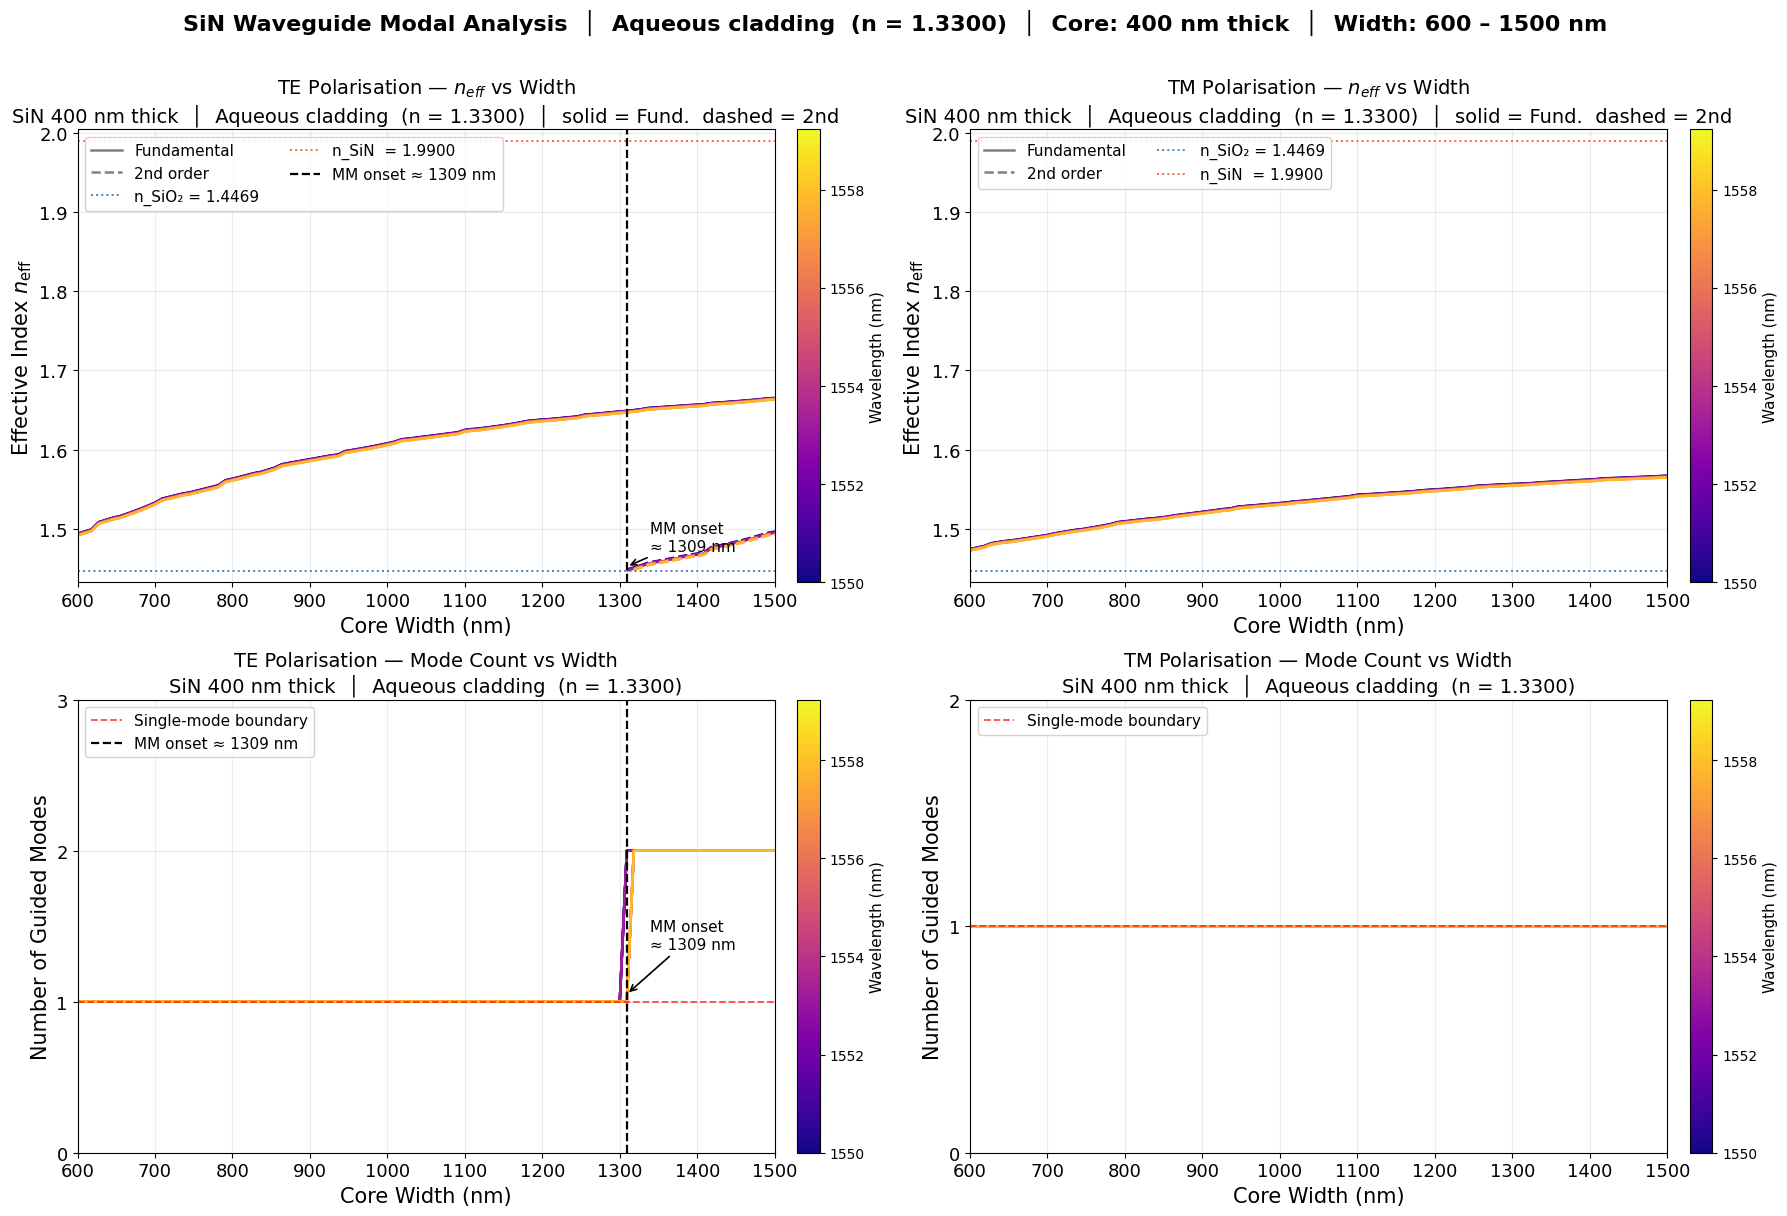


──────────────────────────────────────────────────────────────
  Plotting: Silica cladding
──────────────────────────────────────────────────────────────
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_modal_analysis_sio2clad.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_modal_analysis_sio2clad.pdf


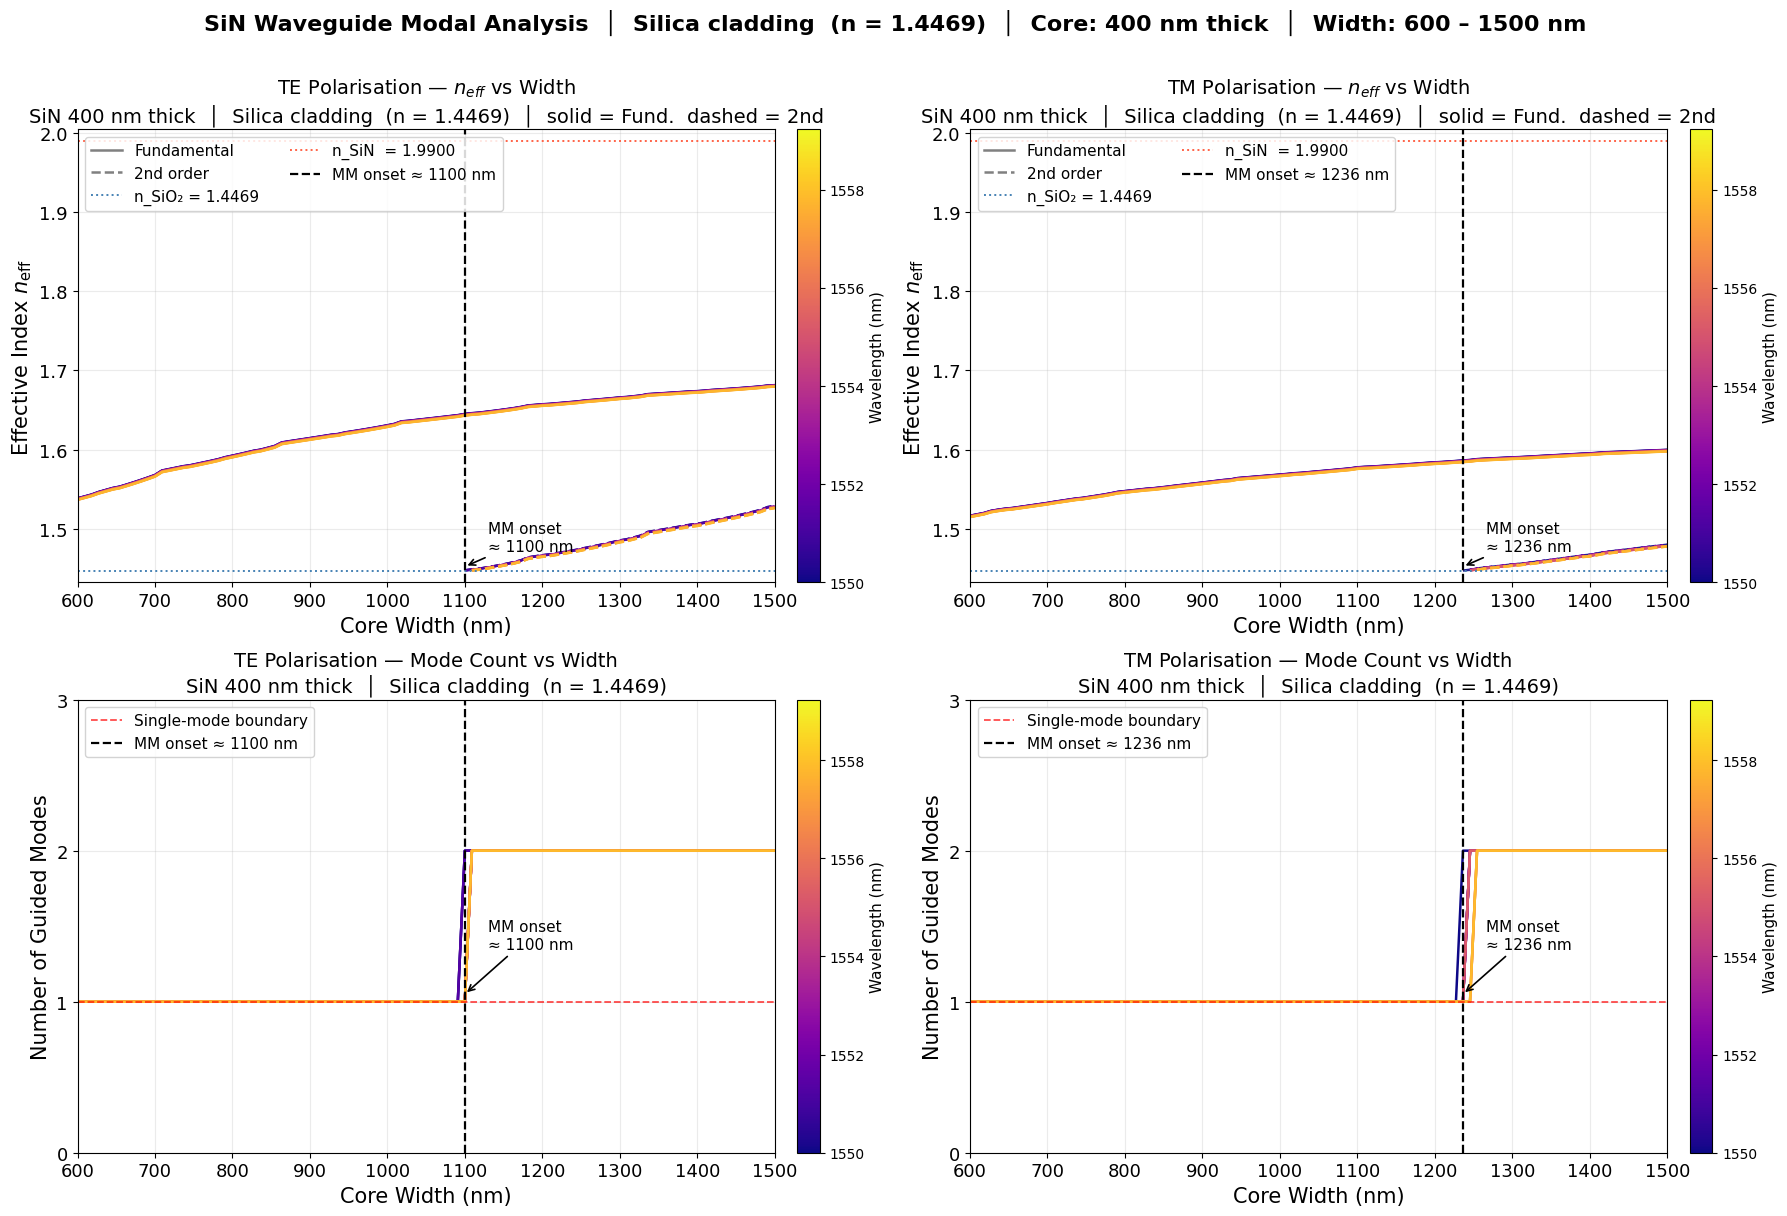

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Post-processing: TE/TM extraction for both cladding sweeps      ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–5 ALREADY EXECUTED.                                       ║
# ║  Reuses without redefining:                                                 ║
# ║    SWEEP_WIDTHS_UM, SWEEP_WL_NM, N_SIN_FIXED, N_SIO2_FIXED,               ║
# ║    N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2, CORE_THICKNESS_UM,            ║
# ║    DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2,                              ║
# ║    neff_real, te_frac, neff_real_sio2, te_frac_sio2,                      ║
# ║    sweep_widths_um, sweep_wl_nm                                            ║
# ║                                                                             ║
# ║  New in this cell:                                                          ║
# ║    matplotlib imports, plotting style constants,                            ║
# ║    extract_pol_data(), find_mm_cutoff_nm(),                                ║
# ║    pol_aq / pol_sio2 dicts                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────
# Plotting style constants  ─ consistent with Tidy3D notebook
# ─────────────────────────────────────────────────────────────────────────────
TE_THRESHOLD    = 0.5               # te_frac > threshold → TE, else TM
MAX_POL_MODES   = 2                 # track up to 2 modes per polarization
PLASMA_RANGE    = (0.0, 0.85)       # crop plasma to avoid bright yellow tip
LINESTYLES      = ['-', '--']       # fund. = solid, 2nd order = dashed
FIG_SIZE_2X2    = (18, 12)
FONT_SUPTITLE   = 16
FONT_TITLE      = 14
FONT_AXLABEL    = 15
FONT_TICK       = 13
FONT_LEGEND     = 11
FONT_CBAR       = 11
FONT_ANNOT      = 11
LEGEND_ALPHA    = 0.85
GRID_ALPHA      = 0.25
SAVE_DPI        = 150


# ─────────────────────────────────────────────────────────────────────────────
# Helper 1:  extract_pol_data
# ─────────────────────────────────────────────────────────────────────────────
def extract_pol_data(neff_real_arr, te_frac_arr, n_guided_cutoff,
                     te_threshold=TE_THRESHOLD, max_modes=MAX_POL_MODES):
    """
    Separate raw FDE mode arrays into TE and TM sub-arrays.

    Modes are visited in Lumerical's natural order (highest neff first).
    A mode qualifies if:
        (a)  Re(neff) > n_guided_cutoff      (guided — above SiO₂ cutoff)
        (b)  te_frac > te_threshold           (TE)
             te_frac ≤ te_threshold           (TM)

    Parameters
    ----------
    neff_real_arr   : np.ndarray  [n_w, n_wl, n_modes]  Re(neff) from FDE
    te_frac_arr     : np.ndarray  [n_w, n_wl, n_modes]  TE polarization fraction
    n_guided_cutoff : float    minimum neff for a guided mode (= N_SIO2_FIXED)
    te_threshold    : float    default 0.5
    max_modes       : int      max modes per polarization to store (default 2)

    Returns
    -------
    dict:
        neff_TE  np.ndarray  [n_w, n_wl, max_modes]  TE neff (NaN = absent)
        neff_TM  np.ndarray  [n_w, n_wl, max_modes]  TM neff
        n_TE     np.ndarray  [n_w, n_wl]  int   guided TE mode count
        n_TM     np.ndarray  [n_w, n_wl]  int   guided TM mode count
    """
    n_w, n_wl, n_mod = neff_real_arr.shape

    neff_TE = np.full((n_w, n_wl, max_modes), np.nan, dtype=np.float64)
    neff_TM = np.full((n_w, n_wl, max_modes), np.nan, dtype=np.float64)
    n_TE    = np.zeros((n_w, n_wl), dtype=np.int32)
    n_TM    = np.zeros((n_w, n_wl), dtype=np.int32)

    for w_i in range(n_w):
        for wl_i in range(n_wl):
            te_cnt = tm_cnt = 0
            for m_i in range(n_mod):
                ne = neff_real_arr[w_i, wl_i, m_i]
                tf = te_frac_arr  [w_i, wl_i, m_i]

                if np.isnan(ne):
                    break                           # no more modes at this point

                if ne <= n_guided_cutoff:
                    continue                        # non-guided; skip

                if tf > te_threshold:               # TE mode
                    if te_cnt < max_modes:
                        neff_TE[w_i, wl_i, te_cnt] = ne
                    te_cnt += 1
                else:                               # TM mode
                    if tm_cnt < max_modes:
                        neff_TM[w_i, wl_i, tm_cnt] = ne
                    tm_cnt += 1

            n_TE[w_i, wl_i] = te_cnt
            n_TM[w_i, wl_i] = tm_cnt

    return dict(neff_TE=neff_TE, neff_TM=neff_TM, n_TE=n_TE, n_TM=n_TM)


# ─────────────────────────────────────────────────────────────────────────────
# Helper 2:  find_mm_cutoff_nm
# ─────────────────────────────────────────────────────────────────────────────
def find_mm_cutoff_nm(n_pol_arr, sweep_widths_um):
    """
    Return the first waveguide width (nm) at which more than one guided mode
    exists for the given polarization across ANY wavelength in the sweep.

    Parameters
    ----------
    n_pol_arr      : [n_w, n_wl]  int   mode count per polarization
    sweep_widths_um: [n_w]        float  width array in µm

    Returns
    -------
    float (nm) if found, None otherwise.
    """
    for w_i in range(len(sweep_widths_um)):
        if np.any(n_pol_arr[w_i, :] > 1):
            return float(sweep_widths_um[w_i] * 1e3)
    return None


# ─────────────────────────────────────────────────────────────────────────────
# Extract polarization data for both sweeps
# n_guided_cutoff = N_SIO2_FIXED for both:
#   aqueous stack : SiO₂ is highest-index cladding → modes leak into SiO₂ first
#   silica  stack : both claddings are SiO₂         → same cutoff
# ─────────────────────────────────────────────────────────────────────────────
pol_aq   = extract_pol_data(neff_real,      te_frac,      N_SIO2_FIXED)
pol_sio2 = extract_pol_data(neff_real_sio2, te_frac_sio2, N_SIO2_FIXED)

# ─────────────────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 66)
print("  Post-processing summary — polarization-resolved mode analysis")
print(f"  Width : {sweep_widths_um[0]*1e3:.0f} → {sweep_widths_um[-1]*1e3:.0f} nm  "
      f"({len(sweep_widths_um)} pts)")
print(f"  λ     : {sweep_wl_nm[0]:.4f} → {sweep_wl_nm[-1]:.4f} nm  "
      f"({len(sweep_wl_nm)} pts,  Δλ = 10/13 nm)")
print("=" * 66)

for env_str, pd, n_uc in [
    (f"Aqueous  (n_upper = {N_UPPER_CLADDING})",    pol_aq,   N_UPPER_CLADDING),
    (f"Silica   (n_upper = {N_UPPER_CLADDING_SIO2:.4f})", pol_sio2, N_UPPER_CLADDING_SIO2),
]:
    c_TE = find_mm_cutoff_nm(pd["n_TE"], sweep_widths_um)
    c_TM = find_mm_cutoff_nm(pd["n_TM"], sweep_widths_um)

    print(f"\n  {env_str}")
    print(f"    TE  max modes = {int(pd['n_TE'].max())}  │  "
          + (f"MM cutoff ≈ {c_TE:.0f} nm" if c_TE else "single-mode across full sweep"))
    print(f"    TM  max modes = {int(pd['n_TM'].max())}  │  "
          + (f"MM cutoff ≈ {c_TM:.0f} nm" if c_TM else "single-mode across full sweep"))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Publication plots: 2 × (2×2 figure)                             ║
# ║                                                                             ║
# ║  Reuses: pol_aq, pol_sio2, sweep_widths_um, sweep_wl_nm,                  ║
# ║           N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2 ║
# ║           CORE_THICKNESS_UM, DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2    ║
# ║           all style constants from Cell 6                                   ║
# ║                                                                             ║
# ║  New: plot_modal_analysis()  (reusable for both environments)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def plot_modal_analysis(
    pol_data,
    sweep_widths_um,
    sweep_wl_nm,
    n_core,
    n_lower_clad,
    n_upper_clad,
    core_thickness_nm,
    env_label,
    save_stem=None,
):
    """
    Generate a 2×2 publication-quality figure for one cladding environment.

    Subplot layout:
        [0,0]  TE   effective index  vs core width   (all wavelengths)
        [0,1]  TM   effective index  vs core width
        [1,0]  TE   guided mode count vs core width
        [1,1]  TM   guided mode count vs core width

    Styling matches the Tidy3D reference notebook:
        plasma colormap for wavelength curves
        solid line = fundamental,  dashed = 2nd order
        steelblue dotted = n_SiO₂ reference
        tomato   dotted = n_SiN  reference
        black dashed vertical = MM onset
        colorbar for wavelength encoding (replaces 13-entry λ legend)

    Parameters
    ----------
    pol_data          : dict  from extract_pol_data
    sweep_widths_um   : [n_w]  µm
    sweep_wl_nm       : [n_wl] nm
    n_core            : float  N_SIN_FIXED
    n_lower_clad      : float  N_SIO2_FIXED
    n_upper_clad      : float  N_UPPER_CLADDING or N_UPPER_CLADDING_SIO2
    core_thickness_nm : float  waveguide height in nm
    env_label         : str    e.g. "Aqueous" or "Silica"
    save_stem         : str or Path or None
                        If given, saves  <save_stem>.png  and  <save_stem>.pdf

    Returns
    -------
    matplotlib.figure.Figure
    """
    neff_TE   = pol_data["neff_TE"]      # [n_w, n_wl, MAX_POL_MODES]
    neff_TM   = pol_data["neff_TM"]
    n_TE_arr  = pol_data["n_TE"]         # [n_w, n_wl]  int
    n_TM_arr  = pol_data["n_TM"]

    n_wl       = len(sweep_wl_nm)
    widths_nm  = sweep_widths_um * 1e3   # µm → nm for x-axis

    # Plasma colormap — one colour per wavelength, consistent with Tidy3D nb
    colors     = plt.cm.plasma(np.linspace(PLASMA_RANGE[0], PLASMA_RANGE[1], n_wl))

    # MM cutoff widths
    cutoff_TE_nm = find_mm_cutoff_nm(n_TE_arr, sweep_widths_um)
    cutoff_TM_nm = find_mm_cutoff_nm(n_TM_arr, sweep_widths_um)

    # ── Figure and axes ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=FIG_SIZE_2X2)

    # ── Shared colorbar setup (wavelength encoding) ───────────────────────────
    _cbar_norm = Normalize(vmin=sweep_wl_nm[0], vmax=sweep_wl_nm[-1])
    _cbar_sm   = cm.ScalarMappable(cmap='plasma', norm=_cbar_norm)
    _cbar_sm.set_array([])

    # ═════════════════════════════════════════════════════════════════════════
    # Inner helper: neff subplot
    # ═════════════════════════════════════════════════════════════════════════
    def _neff_ax(ax, neff_arr, cutoff_nm, pol_str):
        # ── Curve per (wavelength × mode order) ──────────────────────────────
        for wl_i, wl_val in enumerate(sweep_wl_nm):
            col = colors[wl_i]
            for m_i, ls in enumerate(LINESTYLES):
                y = neff_arr[:, wl_i, m_i]
                if np.all(np.isnan(y)):
                    continue
                ax.plot(
                    widths_nm, y,
                    color=col, linewidth=1.8, linestyle=ls,
                    alpha=0.9, label="_nolegend_",
                )

        # ── Reference lines (identical to Tidy3D notebook) ───────────────────
        ax.axhline(n_lower_clad, color='steelblue', linestyle=':', linewidth=1.4,
                   label=f"n_SiO₂ = {n_lower_clad:.4f}")
        ax.axhline(n_core,       color='tomato',    linestyle=':', linewidth=1.4,
                   label=f"n_SiN  = {n_core:.4f}")

        # ── MM cutoff annotation ──────────────────────────────────────────────
        if cutoff_nm is not None:
            ax.axvline(cutoff_nm, color='black', linestyle='--', linewidth=1.6,
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            ax.annotate(
                f"MM onset\n≈ {cutoff_nm:.0f} nm",
                xy         = (cutoff_nm, n_lower_clad + 0.005),
                xytext     = (cutoff_nm + 30, n_lower_clad + 0.025),
                fontsize   = FONT_ANNOT,
                color      = "black",
                arrowprops = dict(arrowstyle="->", color="black", lw=1.2),
            )

        # ── Axis formatting (exact Tidy3D values) ─────────────────────────────
        ax.set_ylim(n_lower_clad - 0.015, n_core + 0.015)
        ax.set_xlim(widths_nm[0], widths_nm[-1])
        ax.set_xlabel("Core Width (nm)",                   fontsize=FONT_AXLABEL)
        ax.set_ylabel(r"Effective Index $n_\mathrm{eff}$", fontsize=FONT_AXLABEL)
        ax.tick_params(axis="both", labelsize=FONT_TICK)
        ax.set_title(
            f"{pol_str} Polarisation — $n_{{eff}}$ vs Width\n"
            f"SiN {core_thickness_nm:.0f} nm thick  │  {env_label} cladding  "
            f"(n = {n_upper_clad:.4f})  │  solid = Fund.  dashed = 2nd",
            fontsize=FONT_TITLE,
        )
        ax.grid(True, alpha=GRID_ALPHA)

        # ── Legend: line-style proxies + reference lines ──────────────────────
        proxy_handles = [
            Line2D([0],[0], color="gray",      linewidth=1.8, linestyle="-",
                   label="Fundamental"),
            Line2D([0],[0], color="gray",      linewidth=1.8, linestyle="--",
                   label="2nd order"),
            Line2D([0],[0], color="steelblue", linewidth=1.4, linestyle=":",
                   label=f"n_SiO₂ = {n_lower_clad:.4f}"),
            Line2D([0],[0], color="tomato",    linewidth=1.4, linestyle=":",
                   label=f"n_SiN  = {n_core:.4f}"),
        ]
        if cutoff_nm is not None:
            proxy_handles.append(
                Line2D([0],[0], color="black", linewidth=1.6, linestyle="--",
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            )
        ax.legend(handles=proxy_handles, fontsize=FONT_LEGEND,
                  ncol=2, loc="upper left", framealpha=LEGEND_ALPHA)

        # ── Wavelength colorbar ───────────────────────────────────────────────
        cbar = fig.colorbar(_cbar_sm, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("Wavelength (nm)", fontsize=FONT_CBAR)
        cbar.ax.tick_params(labelsize=FONT_CBAR - 1)

    # ═════════════════════════════════════════════════════════════════════════
    # Inner helper: mode-count subplot
    # ═════════════════════════════════════════════════════════════════════════
    def _count_ax(ax, n_pol, cutoff_nm, pol_str):
        # ── Curve per wavelength ──────────────────────────────────────────────
        for wl_i, wl_val in enumerate(sweep_wl_nm):
            ax.plot(
                widths_nm, n_pol[:, wl_i],
                color=colors[wl_i], linewidth=1.8,
                label="_nolegend_",
            )

        # ── Single-mode boundary ──────────────────────────────────────────────
        ax.axhline(1, color="red", linestyle="--", linewidth=1.3,
                   alpha=0.7, label="Single-mode boundary")

        # ── MM cutoff ─────────────────────────────────────────────────────────
        if cutoff_nm is not None:
            ax.axvline(cutoff_nm, color="black", linestyle="--", linewidth=1.6,
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            ax.annotate(
                f"MM onset\n≈ {cutoff_nm:.0f} nm",
                xy         = (cutoff_nm, 1.05),
                xytext     = (cutoff_nm + 30, 1.35),
                fontsize   = FONT_ANNOT,
                color      = "black",
                arrowprops = dict(arrowstyle="->", color="black", lw=1.2),
            )

        # ── Axis formatting ───────────────────────────────────────────────────
        max_cnt = int(n_pol.max()) if n_pol.max() > 0 else 2
        ax.set_xlim(widths_nm[0], widths_nm[-1])
        ax.set_ylim(0, max_cnt + 1)
        ax.set_yticks(range(0, max_cnt + 2))
        ax.set_xlabel("Core Width (nm)",          fontsize=FONT_AXLABEL)
        ax.set_ylabel("Number of Guided Modes",   fontsize=FONT_AXLABEL)
        ax.tick_params(axis="both", labelsize=FONT_TICK)
        ax.set_title(
            f"{pol_str} Polarisation — Mode Count vs Width\n"
            f"SiN {core_thickness_nm:.0f} nm thick  │  {env_label} cladding  "
            f"(n = {n_upper_clad:.4f})",
            fontsize=FONT_TITLE,
        )
        ax.grid(True, alpha=GRID_ALPHA)

        # ── Legend: reference lines only ──────────────────────────────────────
        proxy_handles = [
            Line2D([0],[0], color="red",   linewidth=1.3, linestyle="--",
                   alpha=0.7, label="Single-mode boundary"),
        ]
        if cutoff_nm is not None:
            proxy_handles.append(
                Line2D([0],[0], color="black", linewidth=1.6, linestyle="--",
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            )
        ax.legend(handles=proxy_handles, fontsize=FONT_LEGEND,
                  loc="upper left", framealpha=LEGEND_ALPHA)

        # ── Wavelength colorbar ───────────────────────────────────────────────
        cbar = fig.colorbar(_cbar_sm, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("Wavelength (nm)", fontsize=FONT_CBAR)
        cbar.ax.tick_params(labelsize=FONT_CBAR - 1)

    # ── Draw the four subplots ────────────────────────────────────────────────
    _neff_ax (axes[0, 0], neff_TE,  cutoff_TE_nm, "TE")
    _neff_ax (axes[0, 1], neff_TM,  cutoff_TM_nm, "TM")
    _count_ax(axes[1, 0], n_TE_arr, cutoff_TE_nm, "TE")
    _count_ax(axes[1, 1], n_TM_arr, cutoff_TM_nm, "TM")

    fig.suptitle(
        f"SiN Waveguide Modal Analysis  │  {env_label} cladding  "
        f"(n = {n_upper_clad:.4f})  │  "
        f"Core: {core_thickness_nm:.0f} nm thick  │  "
        f"Width: {widths_nm[0]:.0f} – {widths_nm[-1]:.0f} nm",
        fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
    )
    plt.tight_layout()

    if save_stem is not None:
        for ext in (".png", ".pdf"):
            out = str(save_stem) + ext
            plt.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
            print(f"  Saved → {out}")

    plt.show()
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Execute: aqueous cladding
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Plotting: Aqueous cladding")
print("─" * 62)

fig_aq = plot_modal_analysis(
    pol_data          = pol_aq,
    sweep_widths_um   = sweep_widths_um,
    sweep_wl_nm       = sweep_wl_nm,
    n_core            = N_SIN_FIXED,
    n_lower_clad      = N_SIO2_FIXED,
    n_upper_clad      = N_UPPER_CLADDING,
    core_thickness_nm = CORE_THICKNESS_UM * 1e3,
    env_label         = "Aqueous",
    save_stem         = DATA_DIR / f"{VERSION_NAME}_modal_analysis_aqueous",
)

# ─────────────────────────────────────────────────────────────────────────────
# Execute: silica cladding
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Plotting: Silica cladding")
print("─" * 62)

fig_sio2 = plot_modal_analysis(
    pol_data          = pol_sio2,
    sweep_widths_um   = sweep_widths_um,
    sweep_wl_nm       = sweep_wl_nm,
    n_core            = N_SIN_FIXED,
    n_lower_clad      = N_SIO2_FIXED,
    n_upper_clad      = N_UPPER_CLADDING_SIO2,
    core_thickness_nm = CORE_THICKNESS_UM * 1e3,
    env_label         = "Silica",
    save_stem         = DATA_DIR / f"{VERSION_NAME_SIO2}_modal_analysis_sio2clad",
)

Ring waveguide : w = 1000 nm  │  index 44  (actual = 1000.0 nm)
Target FSR     : 10.0 nm  │  1 resonance per ring in the 10 nm interrogation band
Coupling design: CRITICAL COUPLING only  (t = a → T_min = 0)

  Quantity                       TE_aq      TM_aq    TE_sio2    TM_sio2
  ─────────────────────────────────────────────────────────────────
  n_eff @ 1550 nm               1.60795     1.53239     1.63075     1.56839
  n_g   @ 1550 nm               2.02391     1.92649     1.99921     1.91872
  n_g   @ 1559 nm               2.02213     1.92178     1.99734     1.91480

Group index figure saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_group_index_2x2.png / .pdf


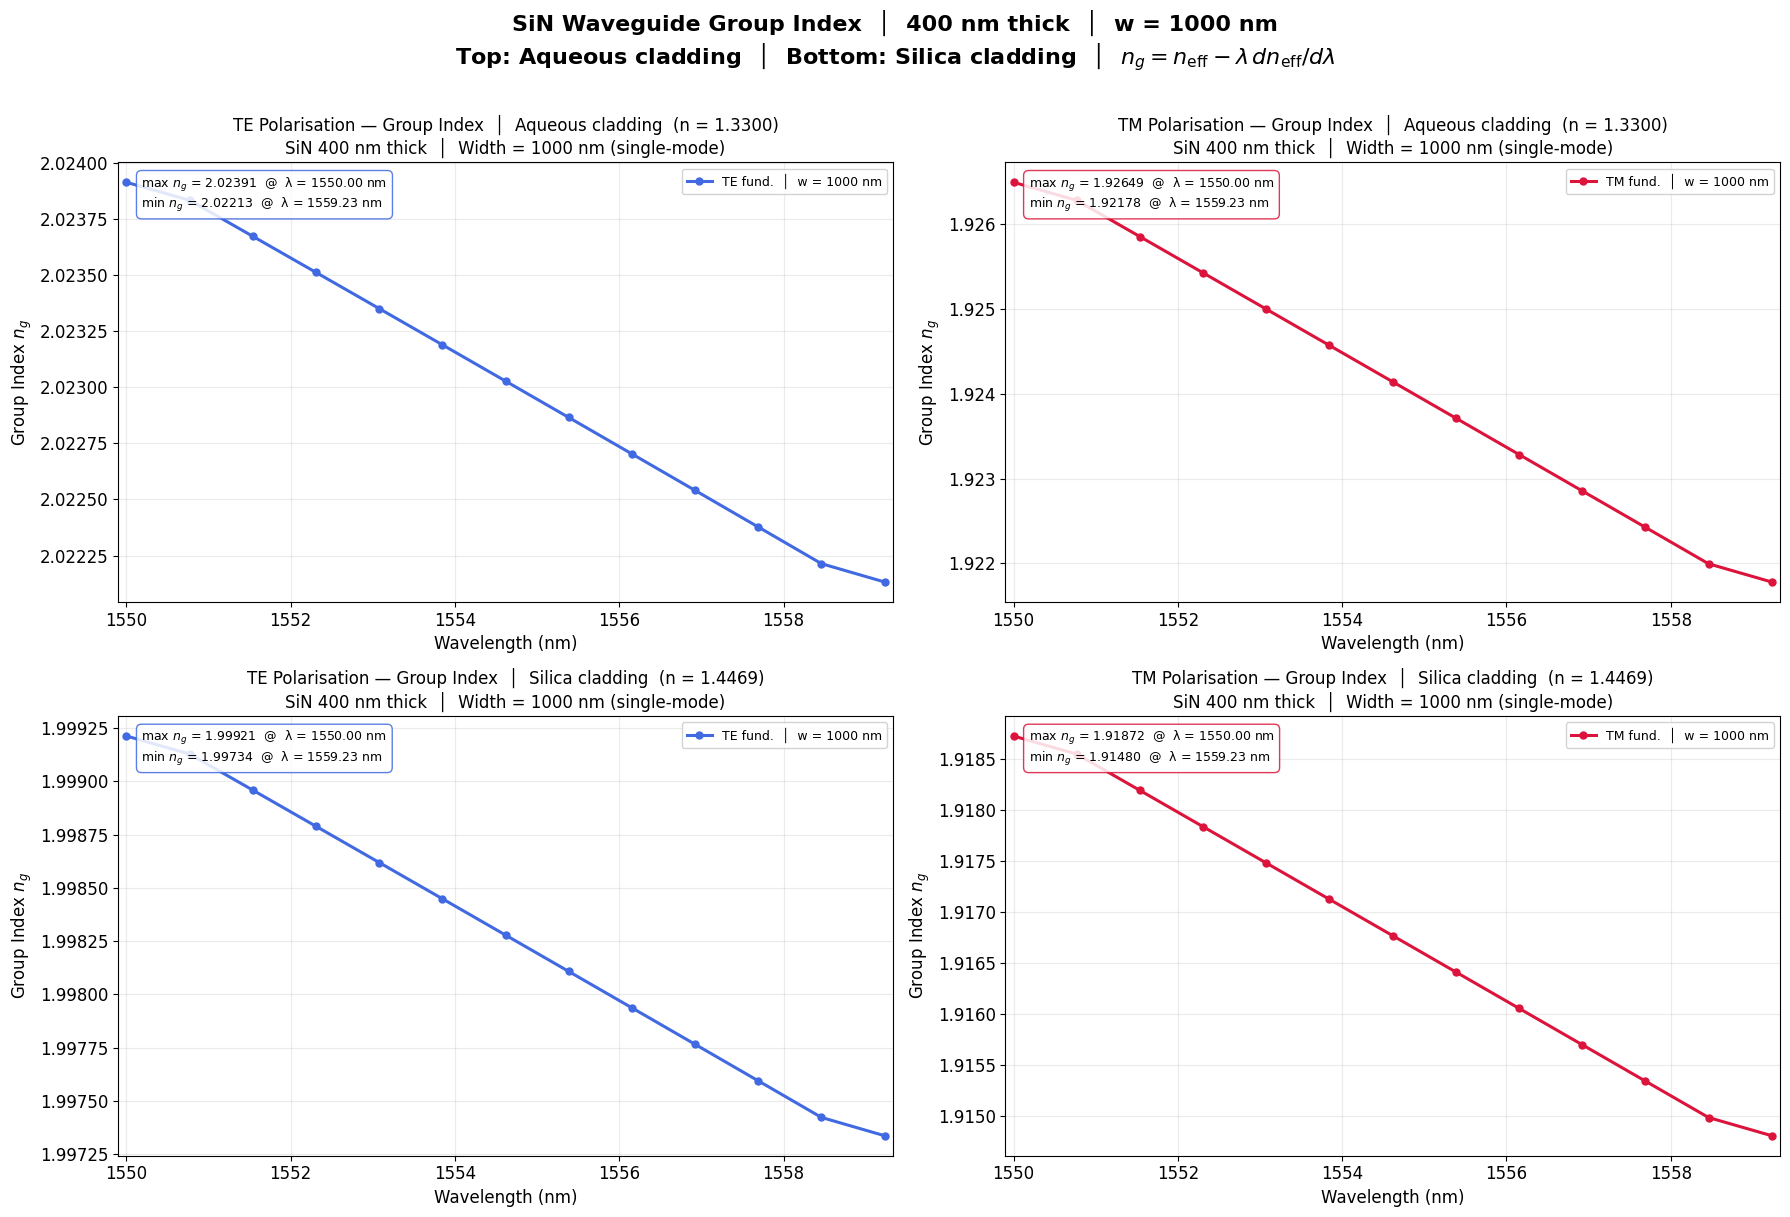


Ring targets: 14 rings defined
  Ring  0 (SENSING) : λ = 1550.00000 nm — Aqueous
  Ring  1 (SPEC)    : λ = 1550.00000 nm — Silica [differential pair with Ring 0]
  Ring 13 (SPEC)    : λ = 1559.23077 nm — Silica

Design complete: 14 rows × 52 columns

══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Ring Physical Dimensions  —  Critical Coupling Design
  FSR_target = 10.0 nm  │  Waveguide: 1000×400 nm  │  t = a  (critical coupling, T_min = 0)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
   ID     Type     Plat      λ(nm)   TE_m   TE_L(µm)   TE_R(µm)   TE_K(%)   TE_FWHM(pm)     TE_Q_L   TM_m   TM_L(µm)   TM_R(µm)   TM_K(%)   TM_FWHM(pm)     TM_Q_L
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    0  SENSING  Aqueous  1550.0000    123   11

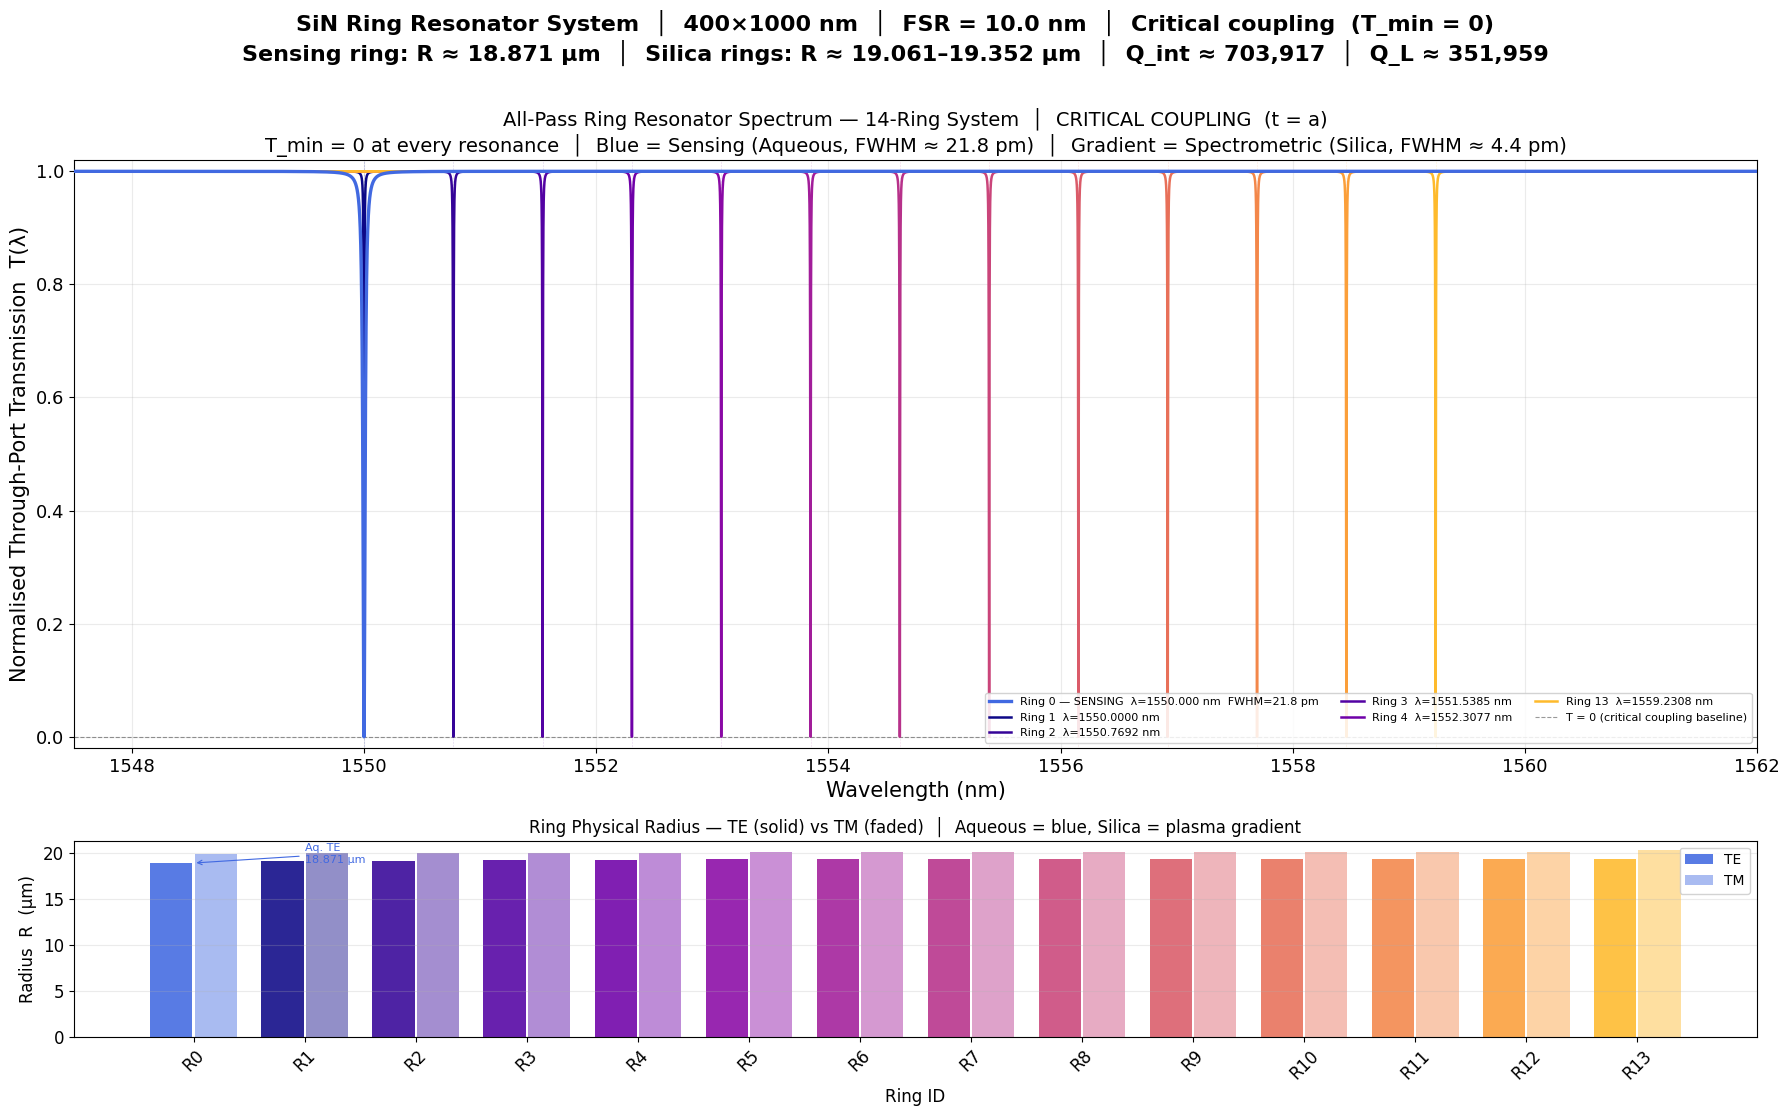

In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Ring design setup: n_g computation + group index plots           ║
# ║                                                                             ║
# ║  CORRECTIONS vs previous version:                                          ║
# ║    · FSR_TARGET_NM = 10 nm  (1 resonance per ring in the 10 nm band)       ║
# ║    · F_TARGET_LINEWIDTH removed — linewidth is NOT engineered; it is       ║
# ║      determined purely by the propagation loss via critical coupling        ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–7 ALREADY EXECUTED.  Reuses without redefining:          ║
# ║    pol_aq, pol_sio2, sweep_widths_um, sweep_wl_nm,                         ║
# ║    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2,    ║
# ║    CORE_THICKNESS_UM, DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2,           ║
# ║    FONT_*, SAVE_DPI, GRID_ALPHA, PLASMA_RANGE, LEGEND_ALPHA                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import pandas as pd   # only new import — all other packages already in namespace

# ─────────────────────────────────────────────────────────────────────────────
# Ring waveguide geometry
# ─────────────────────────────────────────────────────────────────────────────
W_RING_NM   = 1000.0
W_RING_UM   = W_RING_NM * 1e-3
W_RING_IDX  = int(np.argmin(np.abs(sweep_widths_um - W_RING_UM)))   # = 44

# Target FSR = 10 nm
# With 13 spectrometric rings spaced at 10/13 nm across a 10 nm band,
# each ring has exactly ONE resonance in the interrogation window.
# This simplifies spectral readout: ring identity ↔ resonance wavelength,
# one-to-one, without any aliasing or pattern-matching requirement.
FSR_TARGET_NM = 10.0
FSR_TARGET_UM = FSR_TARGET_NM * 1e-3

print(f"Ring waveguide : w = {W_RING_NM:.0f} nm  │  index {W_RING_IDX}"
      f"  (actual = {sweep_widths_um[W_RING_IDX]*1e3:.1f} nm)")
print(f"Target FSR     : {FSR_TARGET_NM} nm  │  "
      f"1 resonance per ring in the 10 nm interrogation band")
print(f"Coupling design: CRITICAL COUPLING only  (t = a → T_min = 0)")

# ─────────────────────────────────────────────────────────────────────────────
# Extract fundamental n_eff at w = 1000 nm for both platforms and polarizations
# ─────────────────────────────────────────────────────────────────────────────
neff_TE_aq    = pol_aq  ["neff_TE"][W_RING_IDX, :, 0].copy()
neff_TM_aq    = pol_aq  ["neff_TM"][W_RING_IDX, :, 0].copy()
neff_TE_sio2  = pol_sio2["neff_TE"][W_RING_IDX, :, 0].copy()
neff_TM_sio2  = pol_sio2["neff_TM"][W_RING_IDX, :, 0].copy()


# ─────────────────────────────────────────────────────────────────────────────
# Group index:  n_g(λ) = n_eff(λ) − λ · dn_eff/dλ
# Central differences (interior), one-sided (endpoints), NaN-safe.
# ─────────────────────────────────────────────────────────────────────────────
def compute_ng(neff_arr, wl_nm_arr):
    """
    Compute group index from n_eff at discrete wavelengths.

    n_g(λ_i) = n_eff(λ_i) − λ_i · [dn_eff/dλ]_i

    Parameters
    ----------
    neff_arr   : np.ndarray  [n_wl]   effective index
    wl_nm_arr  : np.ndarray  [n_wl]   wavelengths in nm

    Returns
    -------
    np.ndarray  [n_wl]   group index
    """
    wl_um = wl_nm_arr * 1e-3
    ng    = np.full_like(neff_arr, np.nan, dtype=np.float64)
    n     = len(wl_nm_arr)

    for i in range(n):
        if np.isnan(neff_arr[i]):
            continue
        if i == 0:
            j, k = 0, 1
        elif i == n - 1:
            j, k = n - 2, n - 1
        else:
            j, k = i - 1, i + 1
        if np.isnan(neff_arr[j]) or np.isnan(neff_arr[k]):
            continue
        dndl  = (neff_arr[k] - neff_arr[j]) / (wl_um[k] - wl_um[j])
        ng[i] = neff_arr[i] - wl_um[i] * dndl

    return ng


ng_TE_aq   = compute_ng(neff_TE_aq,   sweep_wl_nm)
ng_TM_aq   = compute_ng(neff_TM_aq,   sweep_wl_nm)
ng_TE_sio2 = compute_ng(neff_TE_sio2, sweep_wl_nm)
ng_TM_sio2 = compute_ng(neff_TM_sio2, sweep_wl_nm)

# ── Quick n_eff / n_g printout ────────────────────────────────────────────────
hdr = (f"  {'Quantity':<25} {'TE_aq':>10} {'TM_aq':>10} "
       f"{'TE_sio2':>10} {'TM_sio2':>10}")
print(f"\n{hdr}\n  {'─'*65}")
for lbl, *arrs in [
    ("n_eff @ 1550 nm", neff_TE_aq,  neff_TM_aq,  neff_TE_sio2,  neff_TM_sio2),
    ("n_g   @ 1550 nm", ng_TE_aq,    ng_TM_aq,    ng_TE_sio2,    ng_TM_sio2),
    ("n_g   @ 1559 nm", ng_TE_aq,    ng_TM_aq,    ng_TE_sio2,    ng_TM_sio2),
]:
    is_end = "1559" in lbl
    vals   = [a[-1] if is_end else a[0] for a in arrs]
    row    = "  ".join(
        f"{v:10.5f}" if not np.isnan(v) else f"{'NaN':>10}" for v in vals
    )
    print(f"  {lbl:<25}  {row}")


# ─────────────────────────────────────────────────────────────────────────────
# Group index vs wavelength — 2×2 publication figure (Tidy3D Cell 5 style)
# ─────────────────────────────────────────────────────────────────────────────
_NG_COLOR_TE = "royalblue"
_NG_COLOR_TM = "crimson"

_ng_configs = [
    (0, 0, "TE", _NG_COLOR_TE, neff_TE_aq,   ng_TE_aq,   "Aqueous", N_UPPER_CLADDING),
    (0, 1, "TM", _NG_COLOR_TM, neff_TM_aq,   ng_TM_aq,   "Aqueous", N_UPPER_CLADDING),
    (1, 0, "TE", _NG_COLOR_TE, neff_TE_sio2, ng_TE_sio2, "Silica",  N_UPPER_CLADDING_SIO2),
    (1, 1, "TM", _NG_COLOR_TM, neff_TM_sio2, ng_TM_sio2, "Silica",  N_UPPER_CLADDING_SIO2),
]

fig_ng, axes_ng = plt.subplots(2, 2, figsize=FIG_SIZE_2X2)

for row, col, pol_str, clr, neff_arr, ng_arr, env_lbl, n_uc in _ng_configs:
    ax    = axes_ng[row, col]
    valid = ~np.isnan(ng_arr)

    ax.plot(
        sweep_wl_nm[valid], ng_arr[valid],
        color=clr, linewidth=2.2, marker="o", markersize=5,
        label=f"{pol_str} fund.  │  w = {W_RING_NM:.0f} nm",
    )

    if valid.any():
        i_max = int(np.nanargmax(ng_arr));  i_min = int(np.nanargmin(ng_arr))
        ax.text(
            0.03, 0.97,
            f"max $n_g$ = {ng_arr[i_max]:.5f}  @  λ = {sweep_wl_nm[i_max]:.2f} nm\n"
            f"min $n_g$ = {ng_arr[i_min]:.5f}  @  λ = {sweep_wl_nm[i_min]:.2f} nm",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=clr, alpha=LEGEND_ALPHA),
        )

    ax.set_xlabel("Wavelength (nm)",   fontsize=12)
    ax.set_ylabel("Group Index $n_g$", fontsize=12)
    ax.tick_params(axis="both", labelsize=FONT_TICK - 1)
    ax.set_title(
        f"{pol_str} Polarisation — Group Index  │  {env_lbl} cladding  (n = {n_uc:.4f})\n"
        f"SiN {CORE_THICKNESS_UM*1e3:.0f} nm thick  │  Width = {W_RING_NM:.0f} nm (single-mode)",
        fontsize=12,
    )
    ax.legend(fontsize=9, loc="upper right", framealpha=LEGEND_ALPHA)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(sweep_wl_nm[0] - 0.1, sweep_wl_nm[-1] + 0.1)

fig_ng.suptitle(
    f"SiN Waveguide Group Index  │  {CORE_THICKNESS_UM*1e3:.0f} nm thick  │  "
    f"w = {W_RING_NM:.0f} nm\n"
    f"Top: Aqueous cladding  │  Bottom: Silica cladding  │  "
    r"$n_g = n_\mathrm{eff} - \lambda \, dn_\mathrm{eff}/d\lambda$",
    fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
)
plt.tight_layout()
_ng_stem = str(DATA_DIR / f"{VERSION_NAME}_group_index_2x2")
fig_ng.savefig(_ng_stem + ".png", dpi=SAVE_DPI, bbox_inches="tight")
fig_ng.savefig(_ng_stem + ".pdf",              bbox_inches="tight")
print(f"\nGroup index figure saved → {_ng_stem}.png / .pdf")
plt.show()


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Phase-matched ring design with CRITICAL COUPLING                 ║
# ║           for all 14 rings (1 sensing + 13 spectrometric)                  ║
# ║                                                                             ║
# ║  CORRECTIONS vs previous version:                                          ║
# ║    · Scenario B (engineered linewidth) REMOVED entirely                    ║
# ║    · ONLY critical coupling t = a is computed and used                     ║
# ║    · T_min = 0 → resonances dip to zero transmission                       ║
# ║    · AT_TARGET and _solve_at_for_finesse removed                           ║
# ║    · Dedicated ring-dimensions table added (per user request)              ║
# ║                                                                             ║
# ║  PHYSICAL JUSTIFICATION                                                     ║
# ║  At critical coupling t = a:                                               ║
# ║    T_min = [(a − t)/(1 − at)]² = 0   (exact extinction)                   ║
# ║  The FWHM and Q are set by the propagation loss alone:                     ║
# ║    F = π·a/(1 − a²)                                                        ║
# ║    FWHM = FSR / F                                                           ║
# ║    Q_L  = Q_int / 2 = π·n_g·L / (2·λ·|ln a|)                             ║
# ║  No external parameter is needed to "choose" the linewidth.                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# Propagation loss model
# ─────────────────────────────────────────────────────────────────────────────
ALPHA_AQ_DBCM   = 2.5    # aqueous sensing ring  [dB/cm]
ALPHA_SIO2_DBCM = 0.5    # silica reference rings [dB/cm]
GAMMA_AQUEOUS   = 0.20   # field confinement in aqueous cladding (estimated)


# ─────────────────────────────────────────────────────────────────────────────
# design_ring — critical coupling only
# ─────────────────────────────────────────────────────────────────────────────
def design_ring(
    lambda_nm  : float,
    n_eff      : float,
    n_g        : float,
    fsr_target_nm : float,
    alpha_dbcm : float,
) -> dict:
    """
    Phase-matched ring resonator design at CRITICAL COUPLING.

    ═══════════════════════════════════════════════════════════════════
    PHASE MATCHING  (Ansys / Tidy3D methodology)
    ───────────────────────────────────────────────────────────────────
    From  FSR = λ²/(n_g · L):
        L_est = λ² / (n_g · FSR_target)
    From  n_eff · L = m · λ  (resonance condition):
        m_real = n_eff · L_est / λ   →   m = round(m_real)
        L_corr = m · λ / n_eff       (phase-matched perimeter)
        R_corr = L_corr / (2π)

    ═══════════════════════════════════════════════════════════════════
    CRITICAL COUPLING  (t = a)
    ───────────────────────────────────────────────────────────────────
    Round-trip field amplitude:
        a = exp(−α_field · L)   where  α_field = α_power / 2

    At t = a  (coupling field amplitude = round-trip field amplitude):
        T_min = [(a − t)/(1 − at)]² = 0   → COMPLETE EXTINCTION
        K_crit = 1 − a²                    → required power coupling
        F = π · a / (1 − a²)              → finesse
        FWHM = FSR / F                     → resonance linewidth
        Q_int  = π · n_g · L / (λ · |ln a|)
        Q_L   = Q_int / 2                  → loaded Q (= Q_int/2 at crit. coupling)

    No free parameter is adjusted: the linewidth is determined entirely
    by the propagation loss.  This is the physically correct regime for
    a sensor ring: complete extinction maximises signal contrast.

    Parameters
    ----------
    lambda_nm     : target resonance wavelength [nm]
    n_eff         : effective index (from FDE at w = W_RING_NM)
    n_g           : group index (from finite-difference of n_eff vs λ)
    fsr_target_nm : desired FSR [nm]
    alpha_dbcm    : total propagation loss [dB/cm]

    Returns
    -------
    dict — all quantities clearly labelled
    """
    if np.isnan(n_eff) or np.isnan(n_g) or n_eff <= 0 or n_g <= 0:
        nan_keys = [
            "n_eff","n_g","m_real","m","L_est_um","L_corr_um","R_corr_um",
            "perimeter_check_um","fsr_actual_nm","fsr_error_nm","fsr_error_pct",
            "dL_corr_nm","phase_resid_rad","alpha_dbcm","alpha_field_um",
            "a","loss_RT_dB","t_crit","K_crit","T_min",
            "F_crit","FWHM_crit_nm","Q_int","Q_L",
        ]
        return {k: np.nan for k in nan_keys}

    lam_um = lambda_nm * 1e-3

    # ── Phase matching ────────────────────────────────────────────────────────
    L_est_um  = lam_um**2 / (n_g * fsr_target_nm * 1e-3)
    m_real    = n_eff * L_est_um / lam_um
    m         = int(round(m_real))
    L_corr_um = m * lam_um / n_eff
    R_corr_um = L_corr_um / (2.0 * np.pi)

    fsr_actual_nm = (lam_um**2 / (n_g * L_corr_um)) * 1e3
    fsr_error_nm  = fsr_actual_nm - fsr_target_nm
    fsr_error_pct = fsr_error_nm / fsr_target_nm * 100.0
    dL_corr_nm    = (L_corr_um - L_est_um) * 1e3
    phase_resid   = 2.0 * np.pi * (m_real - m)

    # ── Loss model ────────────────────────────────────────────────────────────
    alpha_power_um = alpha_dbcm / (10.0 * np.log10(np.e) * 1.0e4)
    alpha_field_um = alpha_power_um / 2.0
    a              = np.exp(-alpha_field_um * L_corr_um)
    loss_RT_dB     = alpha_dbcm * (L_corr_um * 1e-4)

    # ── Critical coupling (the ONLY design point) ─────────────────────────────
    t_crit       = a
    K_crit       = 1.0 - t_crit**2
    T_min        = ((a - t_crit) / (1.0 - a * t_crit))**2   # = 0.0 exactly
    F_crit       = np.pi * a / (1.0 - a**2)
    FWHM_crit_nm = fsr_actual_nm / F_crit
    Q_int        = np.pi * n_g * L_corr_um / (lam_um * (-np.log(a)))
    Q_L          = Q_int / 2.0   # loaded Q at critical coupling = Q_int / 2

    return {
        # Simulation-derived
        "n_eff"             : float(round(n_eff, 6)),
        "n_g"               : float(round(n_g,   6)),
        # Phase matching
        "m_real"            : float(round(m_real,     4)),
        "m"                 : m,
        "L_est_um"          : float(round(L_est_um,   4)),
        "L_corr_um"         : float(round(L_corr_um,  4)),
        "R_corr_um"         : float(round(R_corr_um,  5)),
        "perimeter_check_um": float(round(2*np.pi*R_corr_um, 4)),
        "fsr_actual_nm"     : float(round(fsr_actual_nm, 5)),
        "fsr_error_nm"      : float(round(fsr_error_nm,  6)),
        "fsr_error_pct"     : float(round(fsr_error_pct, 5)),
        "dL_corr_nm"        : float(round(dL_corr_nm,    4)),
        "phase_resid_rad"   : float(round(phase_resid,   6)),
        # Loss
        "alpha_dbcm"        : float(alpha_dbcm),
        "alpha_field_um"    : float(alpha_field_um),
        "a"                 : float(round(a,           7)),
        "loss_RT_dB"        : float(round(loss_RT_dB,  6)),
        # Critical coupling
        "t_crit"            : float(round(t_crit,       7)),
        "K_crit"            : float(round(K_crit,       7)),
        "T_min"             : float(round(T_min,        10)),   # ≈ 0 always
        "F_crit"            : float(round(F_crit,       2)),
        "FWHM_crit_nm"      : float(round(FWHM_crit_nm, 7)),
        "Q_int"             : int(round(Q_int)),
        "Q_L"               : int(round(Q_L)),
    }


# ─────────────────────────────────────────────────────────────────────────────
# Ring target definitions
# ─────────────────────────────────────────────────────────────────────────────
ring_targets = [
    {"ring_id": 0, "type": "SENSING", "platform": "Aqueous",
     "lambda_nm": float(sweep_wl_nm[0]), "wl_idx": 0,
     "alpha_dbcm": ALPHA_AQ_DBCM},
]
for n in range(13):
    ring_targets.append({
        "ring_id": n + 1, "type": "SPEC", "platform": "Silica",
        "lambda_nm": float(sweep_wl_nm[n]), "wl_idx": n,
        "alpha_dbcm": ALPHA_SIO2_DBCM,
    })

print(f"\nRing targets: {len(ring_targets)} rings defined")
print(f"  Ring  0 (SENSING) : λ = {ring_targets[0]['lambda_nm']:.5f} nm — Aqueous")
print(f"  Ring  1 (SPEC)    : λ = {ring_targets[1]['lambda_nm']:.5f} nm — Silica "
      f"[differential pair with Ring 0]")
print(f"  Ring 13 (SPEC)    : λ = {ring_targets[13]['lambda_nm']:.5f} nm — Silica")


# ─────────────────────────────────────────────────────────────────────────────
# Compute design for all 14 rings × TE + TM
# ─────────────────────────────────────────────────────────────────────────────
table_rows = []

for ring in ring_targets:
    wl_i   = ring["wl_idx"]
    lam_nm = ring["lambda_nm"]
    alpha  = ring["alpha_dbcm"]

    if ring["platform"] == "Aqueous":
        ne_TE, ne_TM = neff_TE_aq[wl_i],   neff_TM_aq[wl_i]
        ng_TE, ng_TM = ng_TE_aq[wl_i],     ng_TM_aq[wl_i]
    else:
        ne_TE, ne_TM = neff_TE_sio2[wl_i], neff_TM_sio2[wl_i]
        ng_TE, ng_TM = ng_TE_sio2[wl_i],   ng_TM_sio2[wl_i]

    d_TE = design_ring(lam_nm, ne_TE, ng_TE, FSR_TARGET_NM, alpha)
    d_TM = design_ring(lam_nm, ne_TM, ng_TM, FSR_TARGET_NM, alpha)

    row = {
        "ring_id"          : ring["ring_id"],
        "type"             : ring["type"],
        "platform"         : ring["platform"],
        "lambda_target_nm" : round(lam_nm, 5),
    }
    for pol, d in [("TE", d_TE), ("TM", d_TM)]:
        for k, v in d.items():
            row[f"{pol}_{k}"] = v
    table_rows.append(row)

df_rings = pd.DataFrame(table_rows)
print(f"\nDesign complete: {len(df_rings)} rows × {len(df_rings.columns)} columns")


# ─────────────────────────────────────────────────────────────────────────────
# TABLE 1 — Ring physical dimensions
# Shows R, L, m for every ring so the user can see the order of size.
# ─────────────────────────────────────────────────────────────────────────────
def _print_ring_dimensions(df):
    """
    Print the physical dimensions (radius and perimeter) for all 14 rings,
    for both TE and TM polarizations.

    This answers the question: "what is the order of size for each ring?"
    Key drivers of size variation:
      · Platform: aqueous vs silica → different n_eff, n_g → different L, R
      · Wavelength: λ increases along spectrometric rings → L ∝ λ²/(n_g·FSR)
      · Polarization: TM has lower n_eff than TE → larger m → larger L, R
    """
    print(f"\n{'═'*130}")
    print(f"  Ring Physical Dimensions  —  Critical Coupling Design")
    print(f"  FSR_target = {FSR_TARGET_NM} nm  │  "
          f"Waveguide: {W_RING_NM:.0f}×{CORE_THICKNESS_UM*1e3:.0f} nm  │  "
          f"t = a  (critical coupling, T_min = 0)")
    print("═"*130)
    print(
        f"  {'ID':>3} {'Type':>8} {'Plat':>8} {'λ(nm)':>10}  "
        f"{'TE_m':>5} {'TE_L(µm)':>10} {'TE_R(µm)':>10} "
        f"{'TE_K(%)':>9} {'TE_FWHM(pm)':>13} {'TE_Q_L':>10}  "
        f"{'TM_m':>5} {'TM_L(µm)':>10} {'TM_R(µm)':>10} "
        f"{'TM_K(%)':>9} {'TM_FWHM(pm)':>13} {'TM_Q_L':>10}"
    )
    print("  " + "─"*126)

    for _, r in df.iterrows():
        def _iv(col): return int(r[col]) if not (isinstance(r[col],float) and np.isnan(r[col])) else -1
        def _fv(col, fmt=".4f"): return f"{r[col]:{fmt}}" if not (isinstance(r[col],float) and np.isnan(r[col])) else "  NaN"

        print(
            f"  {int(r['ring_id']):>3} {r['type']:>8} {r['platform']:>8} "
            f"{r['lambda_target_nm']:>10.4f}  "
            f"{_iv('TE_m'):>5} {_fv('TE_L_corr_um'):>10} {_fv('TE_R_corr_um'):>10} "
            f"{r['TE_K_crit']*100:>9.5f} {r['TE_FWHM_crit_nm']*1e3:>13.4f} "
            f"{_iv('TE_Q_L'):>10,}  "
            f"{_iv('TM_m'):>5} {_fv('TM_L_corr_um'):>10} {_fv('TM_R_corr_um'):>10} "
            f"{r['TM_K_crit']*100:>9.5f} {r['TM_FWHM_crit_nm']*1e3:>13.4f} "
            f"{_iv('TM_Q_L'):>10,}"
        )

    # ── Summary statistics ─────────────────────────────────────────────────
    print("\n  Ring size summary:")
    for pol in ("TE", "TM"):
        r_vals = df[f"{pol}_R_corr_um"].dropna()
        l_vals = df[f"{pol}_L_corr_um"].dropna()
        if r_vals.empty:
            continue
        r_min, r_max = r_vals.min(), r_vals.max()
        l_min, l_max = l_vals.min(), l_vals.max()
        # Separate aqueous vs silica
        aq_r  = df.loc[df["platform"]=="Aqueous",  f"{pol}_R_corr_um"].dropna()
        sio_r = df.loc[df["platform"]=="Silica",   f"{pol}_R_corr_um"].dropna()
        print(
            f"    {pol}: R = {r_min:.4f}–{r_max:.4f} µm  "
            f"(span {(r_max-r_min)*1e3:.1f} nm)  │  "
            f"Aqueous R = {aq_r.mean():.4f} µm  │  "
            f"Silica R = {sio_r.min():.4f}–{sio_r.max():.4f} µm  │  "
            f"L = {l_min:.3f}–{l_max:.3f} µm"
        )

_print_ring_dimensions(df_rings)


# ─────────────────────────────────────────────────────────────────────────────
# TABLE 2 — Full resonator parameter table (TE, critical coupling)
# ─────────────────────────────────────────────────────────────────────────────
def _print_ring_table(df, pol="TE"):
    p = pol
    print(f"\n{'═'*148}")
    print(f"  Ring Resonator Parameters — {pol} Polarisation  │  Critical Coupling (t = a)")
    print(f"  Waveguide: {W_RING_NM:.0f}×{CORE_THICKNESS_UM*1e3:.0f} nm  │  "
          f"FSR_target = {FSR_TARGET_NM} nm  │  "
          f"T_min = 0  (exact extinction at resonance)")
    print("═"*148)
    print(
        f"  {'ID':>3} {'Type':>8} {'Plat':>8} {'λ(nm)':>10} "
        f"{'n_eff':>8} {'n_g':>8} {'m':>5} "
        f"{'R(µm)':>10} {'L(µm)':>10} "
        f"{'FSR(nm)':>9} {'ΔL(nm)':>8} {'φ_res':>8} "
        f"{'a':>9} {'K_crit%':>9} "
        f"{'FWHM(pm)':>10} {'Q_int':>10} {'Q_L':>10}"
    )
    print("  " + "─"*144)

    for _, r in df.iterrows():
        m_v   = int(r[f"{p}_m"]) if not (isinstance(r[f"{p}_m"],float) and np.isnan(r[f"{p}_m"])) else -1
        q_int = int(r[f"{p}_Q_int"]) if not np.isnan(r[f"{p}_Q_int"]) else -1
        q_l   = int(r[f"{p}_Q_L"])   if not np.isnan(r[f"{p}_Q_L"])   else -1

        def _f(v, fmt=".5f"):
            return f"{v:{fmt}}" if not (isinstance(v,float) and np.isnan(v)) else "   NaN"

        print(
            f"  {int(r['ring_id']):>3} {r['type']:>8} {r['platform']:>8} "
            f"{r['lambda_target_nm']:>10.4f} "
            f"{_f(r[f'{p}_n_eff']):>8} {_f(r[f'{p}_n_g']):>8} "
            f"{m_v:>5} "
            f"{_f(r[f'{p}_R_corr_um'],'.4f'):>10} "
            f"{_f(r[f'{p}_L_corr_um'],'.3f'):>10} "
            f"{_f(r[f'{p}_fsr_actual_nm'],'.5f'):>9} "
            f"{_f(r[f'{p}_dL_corr_nm'],'.3f'):>8} "
            f"{_f(r[f'{p}_phase_resid_rad'],'.5f'):>8} "
            f"{_f(r[f'{p}_a'],'.6f'):>9} "
            f"{r[f'{p}_K_crit']*100 if not np.isnan(r[f'{p}_K_crit']) else float('nan'):>9.5f} "
            f"{r[f'{p}_FWHM_crit_nm']*1e3 if not np.isnan(r[f'{p}_FWHM_crit_nm']) else float('nan'):>10.4f} "
            f"{q_int:>10,} {q_l:>10,}"
        )

_print_ring_table(df_rings, "TE")
_print_ring_table(df_rings, "TM")


# ─────────────────────────────────────────────────────────────────────────────
# Supplementary per-ring comparison printout
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*80}")
print("  Critical coupling summary  (sensing ring vs first reference ring, TE)")
print(f"{'─'*80}")
for ri, lbl in [(0, "Ring  0  SENSING"), (1, "Ring  1  SPEC   ")]:
    r = df_rings.iloc[ri]
    print(f"\n  {lbl}  │  λ = {r['lambda_target_nm']:.4f} nm  │  {r['platform']}")
    print(f"    Geometry    :  L = {r['TE_L_corr_um']:.3f} µm  │  "
          f"R = {r['TE_R_corr_um']:.4f} µm  │  m = {int(r['TE_m'])}")
    print(f"    Loss        :  α = {r['TE_alpha_dbcm']:.1f} dB/cm  │  "
          f"a = {r['TE_a']:.6f}  │  RT loss = {r['TE_loss_RT_dB']*1e3:.4f} mdB")
    print(f"    Crit. cpl.  :  t = a = {r['TE_t_crit']:.6f}  │  "
          f"K = {r['TE_K_crit']*100:.5f}%  │  T_min = {r['TE_T_min']:.2e}  (→ 0)")
    print(f"    Resonance   :  FSR = {r['TE_fsr_actual_nm']:.4f} nm  │  "
          f"F = {r['TE_F_crit']:.0f}  │  FWHM = {r['TE_FWHM_crit_nm']*1e3:.4f} pm  │  "
          f"Q_L = {int(r['TE_Q_L']):,}")
    print(f"    Q factors   :  Q_int = {int(r['TE_Q_int']):,}  │  Q_L = Q_int/2 = {int(r['TE_Q_L']):,}")


# ─────────────────────────────────────────────────────────────────────────────
# Save — CSV + HDF5
# ─────────────────────────────────────────────────────────────────────────────
csv_path = DATA_DIR / f"{VERSION_NAME}_ring_design_table.csv"
df_rings.to_csv(csv_path, index=False, float_format="%.7g")
print(f"\nCSV saved  → {csv_path}")

with h5py.File(HDF5_PATH, "r+") as hf:
    grp_key = "ring_design"
    if grp_key in hf:
        del hf[grp_key]
    rg = hf.create_group(grp_key)
    rg.attrs["version_name"]    = VERSION_NAME
    rg.attrs["W_ring_nm"]       = W_RING_NM
    rg.attrs["FSR_target_nm"]   = FSR_TARGET_NM
    rg.attrs["coupling_design"] = "critical_coupling_only"
    rg.attrs["alpha_aq_dbcm"]   = ALPHA_AQ_DBCM
    rg.attrs["alpha_sio2_dbcm"] = ALPHA_SIO2_DBCM
    for col in df_rings.columns:
        try:
            data = df_rings[col].values
            if data.dtype.kind in ("U", "O"):
                data = np.array(data, dtype=h5py.string_dtype())
            rg.create_dataset(col, data=data)
        except Exception:
            pass
print(f"HDF5 saved → {HDF5_PATH}  (group: /ring_design)")


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Resonance spectrum with T_min = 0  (critical coupling)
# ─────────────────────────────────────────────────────────────────────────────
# At critical coupling T_min = 0 → dips reach zero.
# FWHM is very small (4–22 pm): a dense wavelength grid is required.
# 200 000 points over ~15 nm → ~0.075 pm/point → silica dips (4 pm) resolved
# by ≈50 pts and aqueous dips (22 pm) by ≈300 pts.

def _lorentzian_critical(wl_arr, lam_res_nm, fwhm_nm):
    """
    Exact Lorentzian through-port transmission at CRITICAL COUPLING.
    T_min = 0 → T(λ) = 1 − (δ/2)² / [(λ−λ_res)² + (δ/2)²]
    where δ = FWHM.
    """
    half = fwhm_nm / 2.0
    return 1.0 - half**2 / ((wl_arr - lam_res_nm)**2 + half**2)


wl_plot  = np.linspace(1547.5, 1562.0, 200_000)
colors14 = plt.cm.plasma(np.linspace(PLASMA_RANGE[0], PLASMA_RANGE[1], 13))

fig_spec, axes_sp = plt.subplots(
    2, 1, figsize=(18, 11),
    gridspec_kw={"height_ratios": [3, 1]},
)

ax_T = axes_sp[0]   # top: through-port transmission
ax_R = axes_sp[1]   # bottom: ring radius per ring

for row_i, r in df_rings.iterrows():
    lam   = r["lambda_target_nm"]
    ri    = int(r["ring_id"])
    is_s  = (r["type"] == "SENSING")
    fwhm  = r["TE_FWHM_crit_nm"]

    if np.isnan(fwhm):
        continue

    T = _lorentzian_critical(wl_plot, lam, fwhm)

    col  = "royalblue" if is_s else colors14[ri - 1]
    lw   = 2.4         if is_s else 1.8
    zord = 5           if is_s else 3
    lbl  = (f"Ring 0 — SENSING  λ={lam:.3f} nm  FWHM={fwhm*1e3:.1f} pm"
            if is_s
            else (f"Ring {ri}  λ={lam:.4f} nm" if ri <= 4 or ri == 13
                  else "_nolegend_"))

    ax_T.plot(wl_plot, T, color=col, linewidth=lw, label=lbl, zorder=zord)
    # Mark resonance centre with a vertical dotted line
    ax_T.axvline(lam, color=col, linewidth=0.4, alpha=0.35, linestyle=":", zorder=2)

ax_T.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.4,
             label="T = 0 (critical coupling baseline)")
ax_T.set_xlim(wl_plot[0], wl_plot[-1])
ax_T.set_ylim(-0.02, 1.02)
ax_T.set_xlabel("Wavelength (nm)", fontsize=FONT_AXLABEL)
ax_T.set_ylabel("Normalised Through-Port Transmission  T(λ)", fontsize=FONT_AXLABEL)
ax_T.set_title(
    f"All-Pass Ring Resonator Spectrum — 14-Ring System  │  CRITICAL COUPLING  (t = a)\n"
    f"T_min = 0 at every resonance  │  "
    f"Blue = Sensing (Aqueous, FWHM ≈ {df_rings.loc[0,'TE_FWHM_crit_nm']*1e3:.1f} pm)  │  "
    f"Gradient = Spectrometric (Silica, FWHM ≈ {df_rings.loc[1,'TE_FWHM_crit_nm']*1e3:.1f} pm)",
    fontsize=FONT_TITLE,
)
ax_T.tick_params(axis="both", labelsize=FONT_TICK)
ax_T.legend(fontsize=8, ncol=3, loc="lower right", framealpha=LEGEND_ALPHA)
ax_T.grid(True, alpha=GRID_ALPHA)

# ── Bottom panel: ring radius per ring ────────────────────────────────────────
ring_ids  = df_rings["ring_id"].values
R_TE_vals = df_rings["TE_R_corr_um"].values
R_TM_vals = df_rings["TM_R_corr_um"].values
bar_colors = ["royalblue"] + [colors14[i] for i in range(13)]

x_pos = np.arange(len(ring_ids))
ax_R.bar(x_pos - 0.2, R_TE_vals, width=0.38, color=bar_colors, alpha=0.88, label="TE")
ax_R.bar(x_pos + 0.2, R_TM_vals, width=0.38, color=bar_colors, alpha=0.45, label="TM")
ax_R.set_xticks(x_pos)
ax_R.set_xticklabels([f"R{int(i)}" for i in ring_ids], fontsize=8, rotation=45)
ax_R.set_xlabel("Ring ID", fontsize=12)
ax_R.set_ylabel("Radius  R  (µm)", fontsize=12)
ax_R.set_title(
    "Ring Physical Radius — TE (solid) vs TM (faded)  │  "
    "Aqueous = blue, Silica = plasma gradient",
    fontsize=12,
)
ax_R.tick_params(axis="both", labelsize=FONT_TICK - 1)
ax_R.legend(fontsize=10, framealpha=LEGEND_ALPHA)
ax_R.grid(True, alpha=GRID_ALPHA, axis="y")

# Annotate the aqueous ring size
if not np.isnan(R_TE_vals[0]):
    ax_R.annotate(
        f"Aq. TE\n{R_TE_vals[0]:.3f} µm",
        xy=(0, R_TE_vals[0]), xytext=(1.0, R_TE_vals[0] + 0.03),
        fontsize=8, color="royalblue",
        arrowprops=dict(arrowstyle="->", color="royalblue", lw=0.8),
    )

fig_spec.suptitle(
    f"SiN Ring Resonator System  │  {CORE_THICKNESS_UM*1e3:.0f}×{W_RING_NM:.0f} nm  │  "
    f"FSR = {FSR_TARGET_NM} nm  │  Critical coupling  (T_min = 0)\n"
    f"Sensing ring: R ≈ {df_rings.loc[0,'TE_R_corr_um']:.3f} µm  │  "
    f"Silica rings: R ≈ {df_rings.loc[1,'TE_R_corr_um']:.3f}–"
    f"{df_rings.loc[13,'TE_R_corr_um']:.3f} µm  │  "
    f"Q_int ≈ {df_rings.loc[1,'TE_Q_int']:,}  │  Q_L ≈ {df_rings.loc[1,'TE_Q_L']:,}",
    fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
)
plt.tight_layout()
_spec_stem = str(DATA_DIR / f"{VERSION_NAME}_ring_resonance_spectrum")
fig_spec.savefig(_spec_stem + ".png", dpi=SAVE_DPI, bbox_inches="tight")
fig_spec.savefig(_spec_stem + ".pdf",              bbox_inches="tight")
print(f"\nResonance spectrum saved → {_spec_stem}.png / .pdf")
plt.show()